In [32]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
# BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_hsz_best.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_hsz_last.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_hsz_scalers.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype)
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(pred_log, target_log_for_loss, self.log_delta)
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator
      6 -> z0 decision margin feature (repeated across sequence)
      7 -> z1 decision margin feature (repeated across sequence)
      8 -> harmonic_side_z feature (repeated across sequence)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag, z0, z1, harmonic_side_z]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(7, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype)
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:9, :]  # pos, abs, snr, first_flag, z0, z1, harmonic_side_z

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values; cannot use them safely.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = 0.5 * np.sum(past_means, axis=1, keepdims=True).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z1_raw + EPS) + 1.0 / (z0_raw + EPS))
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hsz_raw, temp_hsz_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_side_z_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hsz_raw, te_hsz_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hsz_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    hsz_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hsz = hsz_scaler.fit_transform(t_hsz_raw).astype(np.float32)
    v_hsz = hsz_scaler.transform(v_hsz_raw).astype(np.float32)
    te_hsz = hsz_scaler.transform(te_hsz_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled, z0_scaled, z1_scaled, hsz_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        z0_ch = np.tile(z0_scaled, (1, L)).astype(np.float32)
        z1_ch = np.tile(z1_scaled, (1, L)).astype(np.float32)
        hsz_ch = np.tile(hsz_scaled, (1, L)).astype(np.float32)

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
                z0_ch,
                z1_ch,
                hsz_ch,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr, t_z0, t_z1, t_hsz)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr, v_z0, v_z1, v_hsz)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr, te_z0, te_z1, te_hsz)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "hsz_scaler": hsz_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 9,
        "feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
            "z0_margin",
            "z1_margin",
            "harmonic_side_z",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z1+eps) + 1/(z0+eps))",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.1205 | Val Loss: 0.1204 | Train RMSE(log10): 1.0238 (~10.56x) | Val RMSE(log10): 1.0221 (~10.52x) | Train MAE(log10): 0.3582 | Val MAE(log10): 0.3580 | Train MAE(raw): 0.022827 | Val MAE(raw): 0.022838
  -> New best model saved at epoch 1 with Val Loss: 0.120395
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.2224 | Val Loss: 0.2220 | Train RMSE(log10): 1.6545 (~45.14x) | Val RMSE(log10): 1.6518 (~44.86x) | Train MAE(log10): 0.5961 | Val MAE(log10): 0.5952 | Train MAE(raw): 0.035777 | Val MAE(raw): 0.035779
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.1965 | Val Loss: 0.1964 | Train RMSE(log10): 1.4523 (~28.34x) | Val RMSE(log10): 1.4524 (~28.34x) | Train MAE(log10): 0.5424 | Val MAE(log10): 0.5421 | Train MAE(raw): 0.030171 | Val MAE(raw): 0.030194
Epoch 004 | LR: 1.00e-04 | Train Loss: 0.1239 | Val Loss: 0.1237 | Train RMSE(log10): 1.0702 (~11.75

KeyboardInterrupt: 

In [5]:
import pandas as pd
import numpy as np

EPS = 1e-12

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("data_physics_with_variances_total.csv", nrows=500000)

# Only rows with valid BER and mem_len
df = df[(df["BER"] > 0) & (df["mem_len"] >= 4)].copy()

# High-BER region
df_high = df[df["BER"] >= 1e-3].copy()

# -------------------------
# Identify tap / var columns
# -------------------------
tap_cols = sorted(
    [c for c in df_high.columns if c.startswith("tap_")],
    key=lambda x: int(x.split("_")[1])
)
var_cols = sorted(
    [c for c in df_high.columns if c.startswith("var_")],
    key=lambda x: int(x.split("_")[1])
)

# Fill padded NaNs with 0
df_high[tap_cols] = df_high[tap_cols].fillna(0.0)
df_high[var_cols] = df_high[var_cols].fillna(0.0)
df_high["threshold"] = df_high["threshold"].fillna(0.0)

# -------------------------
# Arrays
# -------------------------
taps = df_high[tap_cols].to_numpy(dtype=np.float64)
vars_ = df_high[var_cols].to_numpy(dtype=np.float64)
threshold = df_high["threshold"].to_numpy(dtype=np.float64).reshape(-1, 1)
y_log = np.log10(df_high["BER"].to_numpy(dtype=np.float64).reshape(-1, 1))

# -------------------------
# Features
# -------------------------
first_mean = taps[:, 0:1]
rest_sum = np.sum(taps[:, 1:], axis=1, keepdims=True)

var_first = vars_[:, 0:1]
var_rest = np.sum(vars_[:, 1:], axis=1, keepdims=True)

mu0 = 0.5 * rest_sum
mu1 = first_mean + mu0

var0 = 0.5 * var_rest
var1 = var_first + var0

first_over_rest_sum = first_mean / (rest_sum + EPS)
first_minus_rest_sum = first_mean - rest_sum
z_sep = (mu1 - mu0) / np.sqrt(np.maximum(var1 + var0, EPS))
thr_pos = (mu1 - threshold) / np.clip(mu1 - mu0, EPS, None)

# -------------------------
# Safe correlation
# -------------------------
def pearson_corr(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan
    if np.std(x) < 1e-15 or np.std(y) < 1e-15:
        return np.nan

    return np.corrcoef(x, y)[0, 1]

features = {
    "first_over_rest_sum": first_over_rest_sum,
    "first_minus_rest_sum": first_minus_rest_sum,
    "z_sep": z_sep,
    "thr_pos": thr_pos,
}

print("High-BER sample count:", len(df_high))
print("Correlation with log10(BER) in high-BER region:")
for name, feat in features.items():
    feat = np.asarray(feat)
    print(
        f"{name:25s} | "
        f"nan_count = {np.isnan(feat).sum():6d} | "
        f"inf_count = {np.isinf(feat).sum():6d} | "
        f"Pearson r = {pearson_corr(feat, y_log):.4f}"
    )

High-BER sample count: 146097
Correlation with log10(BER) in high-BER region:
first_over_rest_sum       | nan_count =      0 | inf_count =      0 | Pearson r = -0.2384
first_minus_rest_sum      | nan_count =      0 | inf_count =      0 | Pearson r = -0.2766
z_sep                     | nan_count =      0 | inf_count =      0 | Pearson r = -0.1783
thr_pos                   | nan_count =      0 | inf_count =      0 | Pearson r = 0.0490


In [6]:
from scipy.stats import spearmanr

print("Spearman correlation with log10(BER) in high-BER region:")
for name, feat in features.items():
    x = np.asarray(feat).reshape(-1)
    y = y_log.reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = spearmanr(x[mask], y[mask])
    print(f"{name:25s} | Spearman r = {r:.4f}")

Spearman correlation with log10(BER) in high-BER region:
first_over_rest_sum       | Spearman r = -0.2939
first_minus_rest_sum      | Spearman r = -0.2924
z_sep                     | Spearman r = -0.1665
thr_pos                   | Spearman r = 0.1908


In [20]:
import numpy as np
from scipy.stats import spearmanr

EPS = 1e-12

# taps: shape [n, L]
first = taps[:, 0:1]
rest = taps[:, 1:]

rest_sum = np.sum(rest, axis=1, keepdims=True)
rest_mean = np.mean(rest, axis=1, keepdims=True)
rest_max = np.max(rest, axis=1, keepdims=True)

mu0 = 0.5 * rest_sum
mu1 = first + mu0

# top-2 rest sum
rest_sorted = np.sort(rest, axis=1)
top2_rest_sum = np.sum(rest_sorted[:, -2:], axis=1, keepdims=True)

# normalized rest weights for entropy
rest_w = rest / (rest_sum + EPS)
rest_entropy = -np.sum(rest_w * np.log(rest_w + EPS), axis=1, keepdims=True)

features2 = {
    "first_minus_rest_mean": first - rest_mean,
    "first_over_rest_mean": first / (rest_mean + EPS),
    "first_log_over_rest_sum": np.log10((first + EPS) / (rest_sum + EPS)),
    "first_log_over_rest_mean": np.log10((first + EPS) / (rest_mean + EPS)),
    "first_minus_maxrest": first - rest_max,
    "first_over_maxrest": first / (rest_max + EPS),
    "first_minus_top2restsum": first - top2_rest_sum,
    "first_over_top2restsum": first / (top2_rest_sum + EPS),
    "first_frac": first / (first + rest_sum + EPS),
    "mu1_minus_thr": mu1 - threshold,
    "thr_minus_mu0": threshold - mu0,
    "min_side_margin": np.minimum(mu1 - threshold, threshold - mu0),
    "rest_max_over_rest_sum": rest_max / (rest_sum + EPS),
    "rest_entropy": rest_entropy,
    "num_rest_gt_0.1first": np.sum(rest > 0.1 * first, axis=1, keepdims=True),
    "num_rest_gt_0.65first": np.sum(rest > 0.65 * first, axis=1, keepdims=True),
    "rest_weighted_index": (
        np.sum(rest * np.arange(1, rest.shape[1] + 1)[None, :], axis=1, keepdims=True)
        / (rest_sum + EPS)
    ),
}

print("Spearman correlation with log10(BER) in high-BER region:")
for name, feat in features2.items():
    x = feat.reshape(-1)
    y = y_log.reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = spearmanr(x[mask], y[mask])
    print(f"{name:28s} | Spearman r = {r:.4f}")

Spearman correlation with log10(BER) in high-BER region:
first_minus_rest_mean        | Spearman r = -0.2866
first_over_rest_mean         | Spearman r = -0.2939
first_log_over_rest_sum      | Spearman r = -0.2939
first_log_over_rest_mean     | Spearman r = -0.2939
first_minus_maxrest          | Spearman r = -0.2960
first_over_maxrest           | Spearman r = -0.2939
first_minus_top2restsum      | Spearman r = -0.2973
first_over_top2restsum       | Spearman r = -0.2939
first_frac                   | Spearman r = -0.2939
mu1_minus_thr                | Spearman r = 0.2532
thr_minus_mu0                | Spearman r = -0.2532
min_side_margin              | Spearman r = 0.2532
rest_max_over_rest_sum       | Spearman r = -0.2939
rest_entropy                 | Spearman r = 0.2939
num_rest_gt_0.1first         | Spearman r = 0.3046
num_rest_gt_0.65first        | Spearman r = 0.4149
rest_weighted_index          | Spearman r = 0.2939


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

EPS = 1e-12

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("data_physics_with_variances_total.csv", nrows=500000)

df = df[(df["BER"] > 0) & (df["mem_len"] >= 4)].copy()
df_high = df[df["BER"] >= 1e-3].copy()

# -------------------------
# Identify tap / var columns
# -------------------------
tap_cols = sorted(
    [c for c in df_high.columns if c.startswith("tap_")],
    key=lambda x: int(x.split("_")[1])
)
var_cols = sorted(
    [c for c in df_high.columns if c.startswith("var_")],
    key=lambda x: int(x.split("_")[1])
)

df_high[tap_cols] = df_high[tap_cols].fillna(0.0)
df_high[var_cols] = df_high[var_cols].fillna(0.0)
df_high["threshold"] = df_high["threshold"].fillna(0.0)

# -------------------------
# Arrays
# -------------------------
taps = df_high[tap_cols].to_numpy(dtype=np.float64)
vars_ = df_high[var_cols].to_numpy(dtype=np.float64)
threshold = df_high["threshold"].to_numpy(dtype=np.float64).reshape(-1, 1)
y_log = np.log10(df_high["BER"].to_numpy(dtype=np.float64).reshape(-1, 1))

first = taps[:, 0:1]
rest = taps[:, 1:]

# -------------------------
# Grounded features
# -------------------------
rest_sum = np.sum(rest, axis=1, keepdims=True)
rest_sq_sum = np.sum(rest**2, axis=1, keepdims=True)
rest_rms = np.sqrt(np.mean(rest**2, axis=1, keepdims=True))
rest_l2 = np.sqrt(rest_sq_sum)

# Total ISI relative to signal
isi_over_signal = rest_sum / (first + EPS)
signal_over_isi = first / (rest_sum + EPS)
log_signal_over_isi = np.log10((first + EPS) / (rest_sum + EPS))

# Soft concentration-aware interference load
soft_isi_ratio2 = np.sum((rest / (first + EPS))**2, axis=1, keepdims=True)
soft_isi_ratio3 = np.sum((rest / (first + EPS))**3, axis=1, keepdims=True)

# Signal vs RMS/L2 interference
signal_over_rms_isi = first / (rest_rms + EPS)
signal_over_l2_isi = first / (rest_l2 + EPS)

# Concentration of interference
rest_sq_over_sum_sq = rest_sq_sum / (rest_sum**2 + EPS)   # larger => a few taps dominate
effective_num_isi = (rest_sum**2) / (rest_sq_sum + EPS)   # smaller => concentrated, larger => spread

# Hypothesis-style quantities if you want to compare
mu0 = 0.5 * rest_sum
mu1 = first + mu0

var_first = vars_[:, 0:1]
var_rest = np.sum(vars_[:, 1:], axis=1, keepdims=True)
var0 = 0.5 * var_rest
var1 = var_first + var0

z_sep = (mu1 - mu0) / np.sqrt(np.maximum(var1 + var0, EPS))

features = {
    "isi_over_signal": isi_over_signal,
    "signal_over_isi": signal_over_isi,
    "log_signal_over_isi": log_signal_over_isi,
    "soft_isi_ratio2": soft_isi_ratio2,
    "soft_isi_ratio3": soft_isi_ratio3,
    "signal_over_rms_isi": signal_over_rms_isi,
    "signal_over_l2_isi": signal_over_l2_isi,
    "rest_sq_over_sum_sq": rest_sq_over_sum_sq,
    "effective_num_isi": effective_num_isi,
    "z_sep": z_sep,
}

# -------------------------
# Correlation helpers
# -------------------------
def safe_spearman(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2 or np.std(x) < 1e-15 or np.std(y) < 1e-15:
        return np.nan
    r, _ = spearmanr(x, y)
    return r

def safe_pearson(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2 or np.std(x) < 1e-15 or np.std(y) < 1e-15:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

print("High-BER sample count:", len(df_high))
print("\nCorrelation with log10(BER) in high-BER region:")
for name, feat in features.items():
    sp = safe_spearman(feat, y_log)
    pr = safe_pearson(feat, y_log)
    print(f"{name:22s} | Spearman r = {sp: .4f} | Pearson r = {pr: .4f}")

High-BER sample count: 146097

Correlation with log10(BER) in high-BER region:
isi_over_signal        | Spearman r =  0.2939 | Pearson r =  0.3016
signal_over_isi        | Spearman r = -0.2939 | Pearson r = -0.2384
log_signal_over_isi    | Spearman r = -0.2939 | Pearson r = -0.2976
soft_isi_ratio2        | Spearman r =  0.2939 | Pearson r =  0.2474
soft_isi_ratio3        | Spearman r =  0.2939 | Pearson r =  0.1853
signal_over_rms_isi    | Spearman r = -0.2939 | Pearson r = -0.2591
signal_over_l2_isi     | Spearman r = -0.2939 | Pearson r = -0.2591
rest_sq_over_sum_sq    | Spearman r = -0.2939 | Pearson r = -0.2560
effective_num_isi      | Spearman r =  0.2939 | Pearson r =  0.3109
z_sep                  | Spearman r = -0.1665 | Pearson r = -0.1783


In [21]:
print(taps)

[[0.08556922 0.04548525 0.02377802 ... 0.         0.         0.        ]
 [0.11113113 0.03940334 0.01936962 ... 0.         0.         0.        ]
 [0.16115051 0.0449309  0.02149829 ... 0.         0.         0.        ]
 ...
 [0.08068176 0.03120422 0.0155153  ... 0.         0.         0.        ]
 [0.14588992 0.04129245 0.01978714 ... 0.         0.         0.        ]
 [0.1316907  0.03926608 0.01891788 ... 0.         0.         0.        ]]


In [23]:
import numpy as np
from scipy.stats import spearmanr

EPS = 1e-12

# taps: raw tap probabilities/means before N scaling
# vars_: raw variances from dataset
# y_log: log10(BER) target

# -------------------------
# Build physically scaled means/stds
# -------------------------
# If you already have N as array shape [n,1], use it directly.
# Example:
N_arr = df_high["N"].to_numpy(dtype=np.float64).reshape(-1, 1)

means = taps * N_arr
stds = np.sqrt(np.maximum(vars_, EPS))

first_mean = means[:, 0:1]
rest_mean = means[:, 1:]

first_std = stds[:, 0:1]
rest_std = stds[:, 1:]

rest_sum = np.sum(rest_mean, axis=1, keepdims=True)
rest_mean_avg = np.mean(rest_mean, axis=1, keepdims=True)
rest_max = np.max(rest_mean, axis=1, keepdims=True)

mu0 = 0.5 * rest_sum
mu1 = first_mean + mu0

# top-2 rest sum
rest_sorted = np.sort(rest_mean, axis=1)
top2_rest_sum = np.sum(rest_sorted[:, -2:], axis=1, keepdims=True)

# normalized rest weights for entropy
rest_w = rest_mean / (rest_sum + EPS)
rest_entropy = -np.sum(rest_w * np.log(rest_w + EPS), axis=1, keepdims=True)

# -------------------------
# New overlap-based dangerous ISI features
# -------------------------
danger_margin = first_mean - first_std
rest_upper = rest_mean + rest_std

dangerous_mask = rest_upper > danger_margin

num_dangerous_isi = np.sum(dangerous_mask, axis=1, keepdims=True)

dangerous_isi_sum = np.sum(rest_mean * dangerous_mask, axis=1, keepdims=True)
dangerous_isi_ratio = dangerous_isi_sum / (first_mean + EPS)

dangerous_overlap_mass = np.sum(
    np.maximum(rest_upper - danger_margin, 0.0),
    axis=1,
    keepdims=True
)

dangerous_overlap_ratio = dangerous_overlap_mass / (first_mean + EPS)

max_overlap = np.max(rest_upper - danger_margin, axis=1, keepdims=True)

features2 = {
    "first_minus_rest_mean": first_mean - rest_mean_avg,
    "first_over_rest_mean": first_mean / (rest_mean_avg + EPS),
    "first_log_over_rest_sum": np.log10((first_mean + EPS) / (rest_sum + EPS)),
    "first_log_over_rest_mean": np.log10((first_mean + EPS) / (rest_mean_avg + EPS)),
    "first_minus_maxrest": first_mean - rest_max,
    "first_over_maxrest": first_mean / (rest_max + EPS),
    "first_minus_top2restsum": first_mean - top2_rest_sum,
    "first_over_top2restsum": first_mean / (top2_rest_sum + EPS),
    "first_frac": first_mean / (first_mean + rest_sum + EPS),
    "mu1_minus_thr": mu1 - threshold,
    "thr_minus_mu0": threshold - mu0,
    "min_side_margin": np.minimum(mu1 - threshold, threshold - mu0),
    "rest_max_over_rest_sum": rest_max / (rest_sum + EPS),
    "rest_entropy": rest_entropy,
    "num_rest_gt_0.1first": np.sum(rest_mean > 0.1 * first_mean, axis=1, keepdims=True),
    "num_rest_gt_0.65first": np.sum(rest_mean > 0.65 * first_mean, axis=1, keepdims=True),
    "rest_weighted_index": (
        np.sum(rest_mean * np.arange(1, rest_mean.shape[1] + 1)[None, :], axis=1, keepdims=True)
        / (rest_sum + EPS)
    ),
    # New theoretically grounded overlap features
    "num_dangerous_isi": num_dangerous_isi,
    "dangerous_isi_sum": dangerous_isi_sum,
    "dangerous_isi_ratio": dangerous_isi_ratio,
    "dangerous_overlap_mass": dangerous_overlap_mass,
    "dangerous_overlap_ratio": dangerous_overlap_ratio,
    "max_overlap": max_overlap,
}

print("Spearman correlation with log10(BER) in high-BER region:")
for name, feat in features2.items():
    x = feat.reshape(-1)
    y = y_log.reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = spearmanr(x[mask], y[mask])
    print(f"{name:28s} | Spearman r = {r:.4f}")

Spearman correlation with log10(BER) in high-BER region:
first_minus_rest_mean        | Spearman r = -0.0406
first_over_rest_mean         | Spearman r = -0.2939
first_log_over_rest_sum      | Spearman r = -0.2939
first_log_over_rest_mean     | Spearman r = -0.2939
first_minus_maxrest          | Spearman r = -0.1491
first_over_maxrest           | Spearman r = -0.2939
first_minus_top2restsum      | Spearman r = -0.2516
first_over_top2restsum       | Spearman r = -0.2939
first_frac                   | Spearman r = -0.2939
mu1_minus_thr                | Spearman r = 0.0902
thr_minus_mu0                | Spearman r = -0.6687
min_side_margin              | Spearman r = -0.8316
rest_max_over_rest_sum       | Spearman r = -0.2939
rest_entropy                 | Spearman r = 0.2939
num_rest_gt_0.1first         | Spearman r = 0.3046
num_rest_gt_0.65first        | Spearman r = 0.4149
rest_weighted_index          | Spearman r = 0.2939
num_dangerous_isi            | Spearman r = 0.3243
dangerous_isi

In [24]:
print(first_mean)

[[  1125.14960844]
 [ 35357.0346908 ]
 [133962.32163875]
 ...
 [   857.08237783]
 [   773.94600838]
 [ 28068.55597643]]


In [25]:
print(first_std)

[[ 32.07602593]
 [177.27878495]
 [335.22265074]
 ...
 [ 28.07011685]
 [ 25.71060267]
 [156.11594463]]


In [26]:
std0 = np.sqrt(np.maximum(var0, EPS))
std1 = np.sqrt(np.maximum(var1, EPS))

side_margin_0 = threshold - mu0
side_margin_1 = mu1 - threshold

z0_side = side_margin_0 / (std0 + EPS)
z1_side = side_margin_1 / (std1 + EPS)

min_side_margin = np.minimum(side_margin_1, side_margin_0)
min_side_z = np.minimum(z1_side, z0_side)

harmonic_side_z = 2.0 / (1.0 / (z1_side + EPS) + 1.0 / (z0_side + EPS))

In [27]:
features_cmp = {
    "min_side_margin": min_side_margin,
    "z0_side": z0_side,
    "z1_side": z1_side,
    "min_side_z": min_side_z,
    "harmonic_side_z": harmonic_side_z,
}

print("Spearman correlation with log10(BER) in high-BER region:")
for name, feat in features_cmp.items():
    x = feat.reshape(-1)
    y = y_log.reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = spearmanr(x[mask], y[mask])
    print(f"{name:20s} | Spearman r = {r:.4f}")

Spearman correlation with log10(BER) in high-BER region:
min_side_margin      | Spearman r = -0.8316
z0_side              | Spearman r = -0.6740
z1_side              | Spearman r = 0.2073
min_side_z           | Spearman r = -0.8867
harmonic_side_z      | Spearman r = -0.8913


In [31]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

EPS = 1e-12

# -------------------------
# Load dataset (example)
# -------------------------
# df should contain: tap_0..tap_L-1, var_0..var_L-1, threshold, N, BER
df = pd.read_csv("data_physics_with_variances_total.csv", nrows=500000)
df = df[(df["BER"] > 0) & (df["mem_len"] >= 4)].copy()
df_high = df[df["BER"] >= 1e-3].copy()  # high BER region for diagnostics

# -------------------------
# Extract taps, variances, threshold, N
# -------------------------
tap_cols = sorted([c for c in df_high.columns if c.startswith("tap_")], key=lambda x: int(x.split("_")[1]))
var_cols = sorted([c for c in df_high.columns if c.startswith("var_")], key=lambda x: int(x.split("_")[1]))

X_taps_feat = df_high[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
X_vars_feat = df_high[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
X_thr_raw = df_high["threshold"].fillna(0.0).to_numpy(dtype=np.float32).reshape(-1,1)
N_arr = df_high["N"].fillna(1.0).to_numpy(dtype=np.float32).reshape(-1,1)
y_log = np.log10(df_high["BER"].to_numpy(dtype=np.float32).reshape(-1,1))

n_samples, L = X_taps_feat.shape

# -------------------------
# Compute global decision statistics
# -------------------------
first_mean = X_taps_feat[:, 0:1] * N_arr
past_means = X_taps_feat[:, 1:] * N_arr
first_var = X_vars_feat[:, 0:1]
past_vars = X_vars_feat[:, 1:]

mu0 = 0.5 * np.sum(past_means, axis=1, keepdims=True)
mu1 = first_mean + mu0

var0 = 0.5 * np.sum(past_vars, axis=1, keepdims=True)
var1 = first_var + var0

std0 = np.sqrt(np.maximum(var0, EPS))
std1 = np.sqrt(np.maximum(var1, EPS))

# -------------------------
# Standard z0/z1 features
# -------------------------
z0 = ((X_thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
z1 = ((mu1 - X_thr_raw) / (std1 + EPS)).astype(np.float32)

# -------------------------
# Harmonic side margin (new)
# -------------------------
z0_side = (X_thr_raw - mu0) / (std0 + EPS)
z1_side = (mu1 - X_thr_raw) / (std1 + EPS)
harmonic_side_z = 2.0 / (1.0 / (z1_side + EPS) + 1.0 / (z0_side + EPS))

# -------------------------
# Additional sequence channels
# -------------------------
pos_ch = np.tile(np.linspace(0.0, 1.0, L, dtype=np.float32), (n_samples, 1))
first_flag = np.zeros((n_samples, L), dtype=np.float32)
first_flag[:, 0] = 1.0

# replicate scalars along sequence
z0_ch = np.tile(z0, (1,L)).astype(np.float32)
z1_ch = np.tile(z1, (1,L)).astype(np.float32)
harmonic_ch = np.tile(harmonic_side_z, (1,L)).astype(np.float32)

# Example SNR proxy (replace with your actual calculation)
snr_raw = np.tile(np.log10(first_mean + EPS), (1,L)).astype(np.float32)

# -------------------------
# Construct final sequence: shape (n_samples, n_channels=9, L)
# -------------------------
seq = np.stack([
    X_taps_feat.astype(np.float32),  # channel 0: scaled tap means
    X_vars_feat.astype(np.float32),  # channel 1: variance
    pos_ch,                          # channel 2: normalized position
    np.abs(X_taps_feat.astype(np.float32)),  # channel 3: abs mean
    snr_raw,                         # channel 4: SNR proxy
    first_flag,                       # channel 5: first flag
    z0_ch,                            # channel 6: z0
    z1_ch,                            # channel 7: z1
    harmonic_ch                       # channel 8: harmonic side margin
], axis=1)

print("Sequence shape:", seq.shape)
print("Spearman correlation of harmonic_side_z with log10(BER):", spearmanr(harmonic_side_z.flatten(), y_log.flatten())[0])

Sequence shape: (146097, 9, 14)
Spearman correlation of harmonic_side_z with log10(BER): -0.8912916985010121


In [33]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

EPS = 1e-12

# -------------------------
# Soft positive transform
# -------------------------
def softplus_np(x, beta=1.0, threshold=20.0):
    """
    Stable NumPy softplus.
    Approximates:
        softplus(x) = (1/beta) * log(1 + exp(beta*x))
    with a linear fallback for large beta*x.
    """
    bx = beta * x
    out = np.where(
        bx > threshold,
        x,
        np.log1p(np.exp(bx)) / beta
    )
    return out.astype(np.float32)


# -------------------------
# Load dataset
# -------------------------
# df should contain: tap_0..tap_L-1, var_0..var_L-1, threshold, N, BER, mem_len
df = pd.read_csv("data_physics_with_variances_total.csv", nrows=500000)
df = df[(df["BER"] > 0) & (df["mem_len"] >= 4)].copy()
df_high = df[df["BER"] >= 1e-3].copy()  # high BER region for diagnostics

# -------------------------
# Extract taps, variances, threshold, N
# -------------------------
tap_cols = sorted(
    [c for c in df_high.columns if c.startswith("tap_")],
    key=lambda x: int(x.split("_")[1])
)
var_cols = sorted(
    [c for c in df_high.columns if c.startswith("var_")],
    key=lambda x: int(x.split("_")[1])
)

X_taps_raw = df_high[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
X_vars_raw = df_high[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
X_thr_raw = df_high["threshold"].fillna(0.0).to_numpy(dtype=np.float32).reshape(-1, 1)
N_arr = df_high["N"].fillna(1.0).to_numpy(dtype=np.float32).reshape(-1, 1)
y_raw = df_high["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)
y_log = np.log10(y_raw + EPS).astype(np.float32)

n_samples, L = X_taps_raw.shape

# -------------------------
# Match training preprocessing
# -------------------------
X_taps_feat = (X_taps_raw * N_arr).astype(np.float32)
X_vars_feat = X_vars_raw.astype(np.float32)

# -------------------------
# Compute global decision statistics
# -------------------------
first_mean = X_taps_feat[:, 0:1]
past_means = X_taps_feat[:, 1:]
first_var = X_vars_feat[:, 0:1]
past_vars = X_vars_feat[:, 1:]

mu0 = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
mu1 = (first_mean + mu0).astype(np.float32)

var0 = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
var1 = (first_var + var0).astype(np.float32)

std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

# -------------------------
# Standard z0/z1 features
# -------------------------
z0 = ((X_thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
z1 = ((mu1 - X_thr_raw) / (std1 + EPS)).astype(np.float32)

# -------------------------
# Harmonic-side variants
# -------------------------

# 1) Original reciprocal form
harmonic_raw = (
    2.0 / (1.0 / (z1 + EPS) + 1.0 / (z0 + EPS))
).astype(np.float32)

# 2) Hard-clipped safe form
z0_pos = np.maximum(z0, 0.0).astype(np.float32)
z1_pos = np.maximum(z1, 0.0).astype(np.float32)
harmonic_clipped = (
    2.0 * z0_pos * z1_pos / (z0_pos + z1_pos + EPS)
).astype(np.float32)

# 3) Soft-clipped form using softplus
# beta controls sharpness:
#   smaller beta -> smoother
#   larger beta -> closer to max(x, 0)
beta = 2.0
z0_soft = softplus_np(z0, beta=beta)
z1_soft = softplus_np(z1, beta=beta)
harmonic_soft = (
    2.0 * z0_soft * z1_soft / (z0_soft + z1_soft + EPS)
).astype(np.float32)

# Optional: even sharper soft version
beta_sharp = 5.0
z0_soft_sharp = softplus_np(z0, beta=beta_sharp)
z1_soft_sharp = softplus_np(z1, beta=beta_sharp)
harmonic_soft_sharp = (
    2.0 * z0_soft_sharp * z1_soft_sharp / (z0_soft_sharp + z1_soft_sharp + EPS)
).astype(np.float32)

# -------------------------
# Additional sequence channels
# -------------------------
pos_ch = np.tile(np.linspace(0.0, 1.0, L, dtype=np.float32), (n_samples, 1))
first_flag = np.zeros((n_samples, L), dtype=np.float32)
first_flag[:, 0] = 1.0

z0_ch = np.tile(z0, (1, L)).astype(np.float32)
z1_ch = np.tile(z1, (1, L)).astype(np.float32)

harmonic_raw_ch = np.tile(harmonic_raw, (1, L)).astype(np.float32)
harmonic_clipped_ch = np.tile(harmonic_clipped, (1, L)).astype(np.float32)
harmonic_soft_ch = np.tile(harmonic_soft, (1, L)).astype(np.float32)

# Match training-style auxiliary channels more closely
abs_taps = np.abs(X_taps_feat).astype(np.float32)
snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_feat + EPS) + EPS).astype(np.float32)

# -------------------------
# Construct final example sequences
# -------------------------
seq_raw = np.stack([
    X_taps_feat,          # 0
    X_vars_feat,          # 1
    pos_ch,               # 2
    abs_taps,             # 3
    snr_raw,              # 4
    first_flag,           # 5
    z0_ch,                # 6
    z1_ch,                # 7
    harmonic_raw_ch       # 8
], axis=1)

seq_clipped = np.stack([
    X_taps_feat,
    X_vars_feat,
    pos_ch,
    abs_taps,
    snr_raw,
    first_flag,
    z0_ch,
    z1_ch,
    harmonic_clipped_ch
], axis=1)

seq_soft = np.stack([
    X_taps_feat,
    X_vars_feat,
    pos_ch,
    abs_taps,
    snr_raw,
    first_flag,
    z0_ch,
    z1_ch,
    harmonic_soft_ch
], axis=1)

print("Sequence shape (raw):     ", seq_raw.shape)
print("Sequence shape (clipped): ", seq_clipped.shape)
print("Sequence shape (soft):    ", seq_soft.shape)

# -------------------------
# Diagnostics
# -------------------------
def safe_spearman(x, y, name):
    mask = np.isfinite(x.reshape(-1)) & np.isfinite(y.reshape(-1))
    corr = spearmanr(x.reshape(-1)[mask], y.reshape(-1)[mask])[0]
    print(f"{name:28s} Spearman with log10(BER): {corr:.6f}")

def print_stats(x, name):
    x_flat = x.reshape(-1)
    finite = np.isfinite(x_flat)
    x_f = x_flat[finite]
    print(
        f"{name:28s} | "
        f"finite={finite.mean():.6f} | "
        f"min={np.min(x_f): .6f} | "
        f"p1={np.percentile(x_f, 1): .6f} | "
        f"p50={np.percentile(x_f, 50): .6f} | "
        f"p99={np.percentile(x_f, 99): .6f} | "
        f"max={np.max(x_f): .6f}"
    )

print("\n=== Feature distribution diagnostics ===")
print_stats(z0, "z0")
print_stats(z1, "z1")
print_stats(harmonic_raw, "harmonic_raw")
print_stats(harmonic_clipped, "harmonic_clipped")
print_stats(harmonic_soft, f"harmonic_soft_beta{beta}")
print_stats(harmonic_soft_sharp, f"harmonic_soft_beta{beta_sharp}")

print("\n=== Correlation diagnostics in high-BER region ===")
safe_spearman(z0, y_log, "z0")
safe_spearman(z1, y_log, "z1")
safe_spearman(harmonic_raw, y_log, "harmonic_raw")
safe_spearman(harmonic_clipped, y_log, "harmonic_clipped")
safe_spearman(harmonic_soft, y_log, f"harmonic_soft_beta{beta}")
safe_spearman(harmonic_soft_sharp, y_log, f"harmonic_soft_beta{beta_sharp}")

# -------------------------
# Optional sanity checks
# -------------------------
print("\n=== Sanity checks ===")
print("harmonic_raw finite ratio:     ", np.isfinite(harmonic_raw).mean())
print("harmonic_clipped finite ratio: ", np.isfinite(harmonic_clipped).mean())
print("harmonic_soft finite ratio:    ", np.isfinite(harmonic_soft).mean())

print("harmonic_clipped zero ratio:   ", np.mean(np.abs(harmonic_clipped) < 1e-12))
print("harmonic_soft near-zero ratio: ", np.mean(np.abs(harmonic_soft) < 1e-6))

/tmp/ipykernel_2328332/3172983554.py:21: RuntimeWarning: overflow encountered in exp
  np.log1p(np.exp(bx)) / beta


Sequence shape (raw):      (146097, 9, 14)
Sequence shape (clipped):  (146097, 9, 14)
Sequence shape (soft):     (146097, 9, 14)

=== Feature distribution diagnostics ===
z0                           | finite=1.000000 | min=-292.263306 | p1=-156.528200 | p50= 8.167012 | p99= 574.828970 | max= 1194.954712
z1                           | finite=1.000000 | min=-115.177979 | p1=-25.272375 | p50= 26.515434 | p99= 329.798148 | max= 593.717346
harmonic_raw                 | finite=1.000000 | min=-5138.999023 | p1=-922.523118 | p50= 1.284901 | p99= 138.570477 | max= 270.468445
harmonic_clipped             | finite=1.000000 | min= 0.000000 | p1= 0.000000 | p50= 1.284901 | p99= 138.570477 | max= 270.468445
harmonic_soft_beta2.0        | finite=1.000000 | min= 0.000000 | p1= 0.000000 | p50= 1.502381 | p99= 138.570477 | max= 270.468445
harmonic_soft_beta5.0        | finite=1.000000 | min= 0.000000 | p1= 0.000000 | p50= 1.299355 | p99= 138.570477 | max= 270.468445

=== Correlation diagnostics in hig

In [34]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

EPS = 1e-12

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("data_physics_with_variances_total.csv", nrows=500000)
df = df[(df["BER"] > 0) & (df["mem_len"] >= 4)].copy()
df_high = df[df["BER"] >= 1e-3].copy()

tap_cols = sorted(
    [c for c in df_high.columns if c.startswith("tap_")],
    key=lambda x: int(x.split("_")[1])
)
var_cols = sorted(
    [c for c in df_high.columns if c.startswith("var_")],
    key=lambda x: int(x.split("_")[1])
)

X_taps_raw = df_high[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
X_vars_raw = df_high[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
threshold = df_high["threshold"].fillna(0.0).to_numpy(dtype=np.float32).reshape(-1, 1)
N_arr = df_high["N"].fillna(1.0).to_numpy(dtype=np.float32).reshape(-1, 1)
y_log = np.log10(df_high["BER"].to_numpy(dtype=np.float32).reshape(-1, 1) + EPS)

# -------------------------
# Match training preprocessing
# -------------------------
X_taps_feat = (X_taps_raw * N_arr).astype(np.float32)
X_vars_feat = X_vars_raw.astype(np.float32)

first_mean = X_taps_feat[:, 0:1]
past_means = X_taps_feat[:, 1:]
first_var = X_vars_feat[:, 0:1]
past_vars = X_vars_feat[:, 1:]

mu0 = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
mu1 = (first_mean + mu0).astype(np.float32)

var0 = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
var1 = (first_var + var0).astype(np.float32)

std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

side_margin_0 = (threshold - mu0).astype(np.float32)
side_margin_1 = (mu1 - threshold).astype(np.float32)

z0_side = (side_margin_0 / (std0 + EPS)).astype(np.float32)
z1_side = (side_margin_1 / (std1 + EPS)).astype(np.float32)

# -------------------------
# Baselines you already tested
# -------------------------
min_side_margin = np.minimum(side_margin_1, side_margin_0).astype(np.float32)
min_side_z = np.minimum(z1_side, z0_side).astype(np.float32)
harmonic_side_z = (
    2.0 / (1.0 / (z1_side + EPS) + 1.0 / (z0_side + EPS))
).astype(np.float32)

# -------------------------
# Additional proposed features
# -------------------------

# 1) Sum-based normalized margin
sum_side_z = (z0_side + z1_side).astype(np.float32)

# 2) Product of normalized margins
prod_side_z = (z0_side * z1_side).astype(np.float32)

# 3) Symmetry / imbalance
abs_diff_side_z = np.abs(z0_side - z1_side).astype(np.float32)

# 4) Sum minus imbalance
lambda_imb = 0.5
sum_minus_imbalance = (sum_side_z - lambda_imb * abs_diff_side_z).astype(np.float32)

# 5) Separation and centeredness
avg_std = (0.5 * (std0 + std1)).astype(np.float32)
sep_norm = ((mu1 - mu0) / (avg_std + EPS)).astype(np.float32)

midpoint = (0.5 * (mu0 + mu1)).astype(np.float32)
offset_norm = ((threshold - midpoint) / (avg_std + EPS)).astype(np.float32)
abs_offset_norm = np.abs(offset_norm).astype(np.float32)

# 6) Separation penalized by off-center threshold
lambda_off = 1.0
sep_minus_offset = (sep_norm - lambda_off * abs_offset_norm).astype(np.float32)

# 7) Validity indicator: threshold lies between means
between_means = ((side_margin_0 > 0) & (side_margin_1 > 0)).astype(np.float32)

# 8) Raw harmonic plus validity-aware interaction
harmonic_times_between = (harmonic_side_z * between_means).astype(np.float32)

# 9) Geometric mean of positive side-z without hard clipping logic in the objective
#    This is just for feature testing, not as an objective.
z0_pos = np.maximum(z0_side, 0.0).astype(np.float32)
z1_pos = np.maximum(z1_side, 0.0).astype(np.float32)
geom_pos_side_z = np.sqrt(z0_pos * z1_pos + EPS).astype(np.float32)

# 10) Signed bottleneck-strength variant
#     keeps sign from min_side_z, magnitude from smaller absolute side
signed_min_abs_side_z = (
    np.sign(np.minimum(z0_side, z1_side)) * np.minimum(np.abs(z0_side), np.abs(z1_side))
).astype(np.float32)

features_cmp = {
    "min_side_margin": min_side_margin,
    "z0_side": z0_side,
    "z1_side": z1_side,
    "min_side_z": min_side_z,
    "harmonic_side_z": harmonic_side_z,
    "sum_side_z": sum_side_z,
    "prod_side_z": prod_side_z,
    "abs_diff_side_z": abs_diff_side_z,
    "sum_minus_imbalance": sum_minus_imbalance,
    "sep_norm": sep_norm,
    "offset_norm": offset_norm,
    "abs_offset_norm": abs_offset_norm,
    "sep_minus_offset": sep_minus_offset,
    "between_means": between_means,
    "harmonic_times_between": harmonic_times_between,
    "geom_pos_side_z": geom_pos_side_z,
    "signed_min_abs_side_z": signed_min_abs_side_z,
}

print("Spearman correlation with log10(BER) in high-BER region:")
for name, feat in features_cmp.items():
    x = feat.reshape(-1)
    y = y_log.reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = spearmanr(x[mask], y[mask])
    print(f"{name:24s} | Spearman r = {r:.4f}")

print("\nFeature diagnostics:")
for name, feat in features_cmp.items():
    x = feat.reshape(-1)
    x = x[np.isfinite(x)]
    print(
        f"{name:24s} | "
        f"min={np.min(x): .4f} | "
        f"p1={np.percentile(x, 1): .4f} | "
        f"p50={np.percentile(x, 50): .4f} | "
        f"p99={np.percentile(x, 99): .4f} | "
        f"max={np.max(x): .4f}"
    )

Spearman correlation with log10(BER) in high-BER region:
min_side_margin          | Spearman r = -0.8315
z0_side                  | Spearman r = -0.6740
z1_side                  | Spearman r = 0.2073
min_side_z               | Spearman r = -0.8866
harmonic_side_z          | Spearman r = -0.8913
sum_side_z               | Spearman r = -0.2369
prod_side_z              | Spearman r = -0.8256
abs_diff_side_z          | Spearman r = 0.4298
sum_minus_imbalance      | Spearman r = -0.6727
sep_norm                 | Spearman r = -0.0855
offset_norm              | Spearman r = -0.4365
abs_offset_norm          | Spearman r = 0.4571
sep_minus_offset         | Spearman r = -0.5562
between_means            | Spearman r = -0.8652
harmonic_times_between   | Spearman r = -0.8562
geom_pos_side_z          | Spearman r = -0.8304
signed_min_abs_side_z    | Spearman r = -0.8866

Feature diagnostics:
min_side_margin          | min=-83788.6172 | p1=-30914.9797 | p50= 10.9914 | p99= 24825.3880 | max= 68902.10

In [57]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, norm

EPS = 1e-12
LOG10E = 1.0 / np.log(10.0)

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("data_physics_with_variances_total.csv", nrows=500000)
df = df[(df["BER"] > 0) & (df["mem_len"] >= 4)].copy()

# low-BER slice
df_low = df[df["BER"] < 1e-6].copy()

tap_cols = sorted(
    [c for c in df_low.columns if c.startswith("tap_")],
    key=lambda x: int(x.split("_")[1])
)
var_cols = sorted(
    [c for c in df_low.columns if c.startswith("var_")],
    key=lambda x: int(x.split("_")[1])
)

X_taps_raw = df_low[tap_cols].fillna(0.0).to_numpy(dtype=np.float64)
X_vars_raw = df_low[var_cols].fillna(0.0).to_numpy(dtype=np.float64)
threshold = df_low["threshold"].fillna(0.0).to_numpy(dtype=np.float64).reshape(-1, 1)
N_arr = df_low["N"].fillna(1.0).to_numpy(dtype=np.float64).reshape(-1, 1)
y_log = np.log10(df_low["BER"].to_numpy(dtype=np.float64).reshape(-1, 1) + EPS)

# -------------------------
# Match training preprocessing
# -------------------------
X_taps_feat = (X_taps_raw * N_arr).astype(np.float64)
X_vars_feat = X_vars_raw.astype(np.float64)

first_mean = X_taps_feat[:, 0:1]
past_means = X_taps_feat[:, 1:]
first_var = X_vars_feat[:, 0:1]
past_vars = X_vars_feat[:, 1:]

mu0 = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float64)
mu1 = (first_mean + mu0).astype(np.float64)

var0 = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float64)
var1 = (first_var + var0).astype(np.float64)

std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float64)
std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float64)

side_margin_0 = (threshold - mu0).astype(np.float64)
side_margin_1 = (mu1 - threshold).astype(np.float64)

z0_side = (side_margin_0 / (std0 + EPS)).astype(np.float64)
z1_side = (side_margin_1 / (std1 + EPS)).astype(np.float64)

# -------------------------
# Best previous baselines
# -------------------------
min_side_margin = np.minimum(side_margin_1, side_margin_0).astype(np.float64)
min_side_z = np.minimum(z1_side, z0_side).astype(np.float64)

harmonic_side_z = (
    2.0 / (1.0 / (z1_side + EPS) + 1.0 / (z0_side + EPS))
).astype(np.float64)

avg_std = (0.5 * (std0 + std1)).astype(np.float64)
sep_norm = ((mu1 - mu0) / (avg_std + EPS)).astype(np.float64)

midpoint = (0.5 * (mu0 + mu1)).astype(np.float64)
offset_norm = ((threshold - midpoint) / (avg_std + EPS)).astype(np.float64)
abs_offset_norm = np.abs(offset_norm).astype(np.float64)

sep_minus_offset = (sep_norm - abs_offset_norm).astype(np.float64)
abs_diff_side_z = np.abs(z0_side - z1_side).astype(np.float64)

# -------------------------
# Stable new low-BER features
# -------------------------
# Use stable Gaussian log-tail features
logQ0 = norm.logsf(z0_side)   # ln Q(z0)
logQ1 = norm.logsf(z1_side)   # ln Q(z1)

# Exact two-sided Gaussian BER proxy in log10 domain:
# log10(0.5 * (Q(z0) + Q(z1)))
log10_ber_pair_sf = ((np.logaddexp(logQ0, logQ1) - np.log(2.0)) * LOG10E).astype(np.float64)

# Worst-side Gaussian tail proxy:
# log10(max(Q(z0), Q(z1))) = max(logQ0, logQ1)/ln(10)
log10_ber_worst_sf = (np.maximum(logQ0, logQ1) * LOG10E).astype(np.float64)

# Tail strengths, monotone in the "good" direction
tail_strength_pair = (-log10_ber_pair_sf).astype(np.float64)
tail_strength_worst = (-log10_ber_worst_sf).astype(np.float64)

# Tail imbalance in log domain
logQ_gap = np.abs(logQ0 - logQ1).astype(np.float64)
log10Q_gap = (logQ_gap * LOG10E).astype(np.float64)

# -------------------------
# New hybrid features guided by your results
# -------------------------
# 1) harmonic with explicit imbalance penalty
lambda_gap = 0.25
harmonic_minus_gap = (harmonic_side_z - lambda_gap * abs_diff_side_z).astype(np.float64)

# 2) harmonic normalized by imbalance
harmonic_over_gap = (harmonic_side_z / (1.0 + abs_diff_side_z)).astype(np.float64)

# 3) separation normalized by threshold off-centering
sep_over_offset = (sep_norm / (1.0 + abs_offset_norm)).astype(np.float64)

# 4) combine the two best families
sep_harmonic_mean = (0.5 * (sep_minus_offset + harmonic_side_z)).astype(np.float64)

# 5) geometric combination of the two best families
sep_harmonic_geom = np.sqrt(
    np.maximum(sep_minus_offset, 0.0) * np.maximum(harmonic_side_z, 0.0) + EPS
).astype(np.float64)

# 6) stable tail strength plus balance penalty
lambda_loggap = 0.10
tail_pair_minus_gap = (tail_strength_pair - lambda_loggap * log10Q_gap).astype(np.float64)

# 7) worst-side tail plus balance penalty
tail_worst_minus_gap = (tail_strength_worst - lambda_loggap * log10Q_gap).astype(np.float64)

# 8) separation + stable tail
lambda_tail = 0.10
sep_plus_tail = (sep_minus_offset + lambda_tail * tail_strength_pair).astype(np.float64)

# 9) harmonic + stable tail
harmonic_plus_tail = (harmonic_side_z + lambda_tail * tail_strength_worst).astype(np.float64)

# 10) bottleneck z with asymmetry penalty
z_balanced = (min_side_z - 0.25 * abs_diff_side_z).astype(np.float64)

# -------------------------
# Candidates to compare
# -------------------------
features_cmp = {
    # strongest old ones
    "min_side_margin": min_side_margin,
    "min_side_z": min_side_z,
    "harmonic_side_z": harmonic_side_z,
    "sep_minus_offset": sep_minus_offset,

    # stable new tail features
    "log10_ber_pair_sf": log10_ber_pair_sf,
    "log10_ber_worst_sf": log10_ber_worst_sf,
    "tail_strength_pair": tail_strength_pair,
    "tail_strength_worst": tail_strength_worst,
    "log10Q_gap": log10Q_gap,

    # hybrids based on your best results
    "harmonic_minus_gap": harmonic_minus_gap,
    "harmonic_over_gap": harmonic_over_gap,
    "sep_over_offset": sep_over_offset,
    "sep_harmonic_mean": sep_harmonic_mean,
    "sep_harmonic_geom": sep_harmonic_geom,
    "tail_pair_minus_gap": tail_pair_minus_gap,
    "tail_worst_minus_gap": tail_worst_minus_gap,
    "sep_plus_tail": sep_plus_tail,
    "harmonic_plus_tail": harmonic_plus_tail,
    "z_balanced": z_balanced,
}

# -------------------------
# Rank by absolute Spearman
# -------------------------
rows = []
print("Spearman correlation with log10(BER) in low-BER region:")
for name, feat in features_cmp.items():
    x = feat.reshape(-1)
    y = y_log.reshape(-1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size == 0 or np.allclose(x, x[0]):
        r = np.nan
    else:
        r, _ = spearmanr(x, y)

    rows.append({
        "feature": name,
        "spearman_r": r,
        "abs_spearman_r": np.nan if np.isnan(r) else abs(r),
        "min": np.min(x) if x.size else np.nan,
        "p1": np.percentile(x, 1) if x.size else np.nan,
        "p50": np.percentile(x, 50) if x.size else np.nan,
        "p99": np.percentile(x, 99) if x.size else np.nan,
        "max": np.max(x) if x.size else np.nan,
    })

    print(f"{name:22s} | Spearman r = {r:.4f}" if not np.isnan(r) else f"{name:22s} | Spearman r = nan")

summary = pd.DataFrame(rows).sort_values("abs_spearman_r", ascending=False)
print("\nRanked by |Spearman r|:")
print(summary[["feature", "spearman_r", "abs_spearman_r"]].to_string(index=False))

print("\nFeature diagnostics:")
print(summary[["feature", "min", "p1", "p50", "p99", "max"]].to_string(index=False))

# Optional: save
summary.to_csv("low_ber_feature_screening_results.csv", index=False)
print("\nSaved: low_ber_feature_screening_results.csv")

Spearman correlation with log10(BER) in low-BER region:
min_side_margin        | Spearman r = -0.5834
min_side_z             | Spearman r = -0.5776
harmonic_side_z        | Spearman r = -0.5924
sep_minus_offset       | Spearman r = -0.5929
log10_ber_pair_sf      | Spearman r = 0.5776
log10_ber_worst_sf     | Spearman r = 0.5776
tail_strength_pair     | Spearman r = -0.5776
tail_strength_worst    | Spearman r = -0.5776
log10Q_gap             | Spearman r = -0.4938
harmonic_minus_gap     | Spearman r = -0.6009
harmonic_over_gap      | Spearman r = -0.0247
sep_over_offset        | Spearman r = -0.1879
sep_harmonic_mean      | Spearman r = -0.5930
sep_harmonic_geom      | Spearman r = -0.5933
tail_pair_minus_gap    | Spearman r = -0.3594
tail_worst_minus_gap   | Spearman r = -0.3594
sep_plus_tail          | Spearman r = -0.5869
harmonic_plus_tail     | Spearman r = -0.5837
z_balanced             | Spearman r = -0.4755

Ranked by |Spearman r|:
             feature  spearman_r  abs_spearman_

In [53]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
# BASE_DIR = "/mnt/erencem-ozbey/ber_estimation"
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_minsidez_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_minsidez_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_minsidez_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype)
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(pred_log, target_log_for_loss, self.log_delta)
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Input seq channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy (scaled separately)
      5 -> first-position indicator
      6 -> z0 decision margin feature (repeated across sequence)
      7 -> z1 decision margin feature (repeated across sequence)
      8 -> min_side_z feature (repeated across sequence)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag, z0, z1, min_side_z]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(7, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype)
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:9, :]  # pos, abs, snr, first_flag, z0, z1, min_side_z

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values; cannot use them safely.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = 0.5 * np.sum(past_means, axis=1, keepdims=True).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled, z0_scaled, z1_scaled, msz_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        z0_ch = np.tile(z0_scaled, (1, L)).astype(np.float32)
        z1_ch = np.tile(z1_scaled, (1, L)).astype(np.float32)
        msz_ch = np.tile(msz_scaled, (1, L)).astype(np.float32)

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
                z0_ch,
                z1_ch,
                msz_ch,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    t_seq = build_features(t_taps, t_vars, t_abs, t_snr, t_z0, t_z1, t_msz)
    v_seq = build_features(v_taps, v_vars, v_abs, v_snr, v_z0, v_z1, v_msz)
    te_seq = build_features(te_taps, te_vars, te_abs, te_snr, te_z0, te_z1, te_msz)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 9,
        "feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
            "z0_margin",
            "z1_margin",
            "min_side_z",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(f"  -> New best model saved at epoch {epoch+1} with Val Loss: {val_loss:.6f}")
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0523 | Val Loss: 0.0525 | Train RMSE(log10): 0.5923 (~3.91x) | Val RMSE(log10): 0.5923 (~3.91x) | Train MAE(log10): 0.1884 | Val MAE(log10): 0.1887 | Train MAE(raw): 0.020064 | Val MAE(raw): 0.020046
  -> New best model saved at epoch 1 with Val Loss: 0.052452
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0351 | Val Loss: 0.0351 | Train RMSE(log10): 0.4366 (~2.73x) | Val RMSE(log10): 0.4366 (~2.73x) | Train MAE(log10): 0.1611 | Val MAE(log10): 0.1610 | Train MAE(raw): 0.025282 | Val MAE(raw): 0.025308
  -> New best model saved at epoch 2 with Val Loss: 0.035098
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0332 | Val Loss: 0.0331 | Train RMSE(log10): 0.4540 (~2.84x) | Val RMSE(log10): 0.4518 (~2.83x) | Train MAE(log10): 0.1577 | Val MAE(log10): 0.1575 | Train MAE(raw): 0.028115 | Val MAE(raw): 0.028121
  -> New best model saved at epoch 3 with Val

Epoch 033 | LR: 3.13e-06 | Train Loss: 0.0147 | Val Loss: 0.0148 | Train RMSE(log10): 0.2240 (~1.67x) | Val RMSE(log10): 0.2247 (~1.68x) | Train MAE(log10): 0.0856 | Val MAE(log10): 0.0860 | Train MAE(raw): 0.013985 | Val MAE(raw): 0.013998
Epoch 034 | LR: 3.13e-06 | Train Loss: 0.0144 | Val Loss: 0.0145 | Train RMSE(log10): 0.2542 (~1.80x) | Val RMSE(log10): 0.2544 (~1.80x) | Train MAE(log10): 0.0824 | Val MAE(log10): 0.0826 | Train MAE(raw): 0.013601 | Val MAE(raw): 0.013612
Epoch 035 | LR: 3.13e-06 | Train Loss: 0.0168 | Val Loss: 0.0169 | Train RMSE(log10): 0.2573 (~1.81x) | Val RMSE(log10): 0.2578 (~1.81x) | Train MAE(log10): 0.0905 | Val MAE(log10): 0.0908 | Train MAE(raw): 0.014009 | Val MAE(raw): 0.014022
Epoch 036 | LR: 3.13e-06 | Train Loss: 0.0115 | Val Loss: 0.0116 | Train RMSE(log10): 0.1887 (~1.54x) | Val RMSE(log10): 0.1891 (~1.55x) | Train MAE(log10): 0.0762 | Val MAE(log10): 0.0765 | Train MAE(raw): 0.013112 | Val MAE(raw): 0.013124
Epoch 037 | LR: 1.56e-06 | Train Los

Epoch 067 | LR: 2.44e-08 | Train Loss: 0.0212 | Val Loss: 0.0213 | Train RMSE(log10): 0.3044 (~2.02x) | Val RMSE(log10): 0.3048 (~2.02x) | Train MAE(log10): 0.1000 | Val MAE(log10): 0.1003 | Train MAE(raw): 0.012910 | Val MAE(raw): 0.012923
Epoch 068 | LR: 2.44e-08 | Train Loss: 0.0182 | Val Loss: 0.0182 | Train RMSE(log10): 0.2966 (~1.98x) | Val RMSE(log10): 0.2963 (~1.98x) | Train MAE(log10): 0.0943 | Val MAE(log10): 0.0945 | Train MAE(raw): 0.015012 | Val MAE(raw): 0.015032
Epoch 069 | LR: 2.44e-08 | Train Loss: 0.0154 | Val Loss: 0.0155 | Train RMSE(log10): 0.2356 (~1.72x) | Val RMSE(log10): 0.2362 (~1.72x) | Train MAE(log10): 0.0859 | Val MAE(log10): 0.0862 | Train MAE(raw): 0.012847 | Val MAE(raw): 0.012859
Epoch 070 | LR: 2.44e-08 | Train Loss: 0.0221 | Val Loss: 0.0222 | Train RMSE(log10): 0.2735 (~1.88x) | Val RMSE(log10): 0.2743 (~1.88x) | Train MAE(log10): 0.1029 | Val MAE(log10): 0.1033 | Train MAE(raw): 0.012698 | Val MAE(raw): 0.012711
Epoch 071 | LR: 2.44e-08 | Train Los

In [ ]:
Epoch 071 | LR: 9.77e-08 | Train Loss: 0.0129 | Val Loss: 0.0130 | Train RMSE(log10): 0.1900 (~1.55x) | Val RMSE(log10): 0.1909 (~1.55x) | Train MAE(log10): 0.1073 | Val MAE(log10): 0.1076 | Train MAE(raw): 0.021913 | Val MAE(raw): 0.021944
Early stopping triggered.
Last model saved to: ./ber_boundedloghalf_minsidez_last.pth
Best model saved to: ./ber_boundedloghalf_minsidez_best.pth
Test Loss: 0.0095 | Test RMSE(log10): 0.1573 | Test MAE(log10): 0.0983 | Typical multiplicative error: ~1.44x | Test RMSE(raw): 0.032179 | Test MAE(raw): 0.021432

Per-range test diagnostics:
low_BER(y<1e-6) | count=9585 | RMSE(log10)=0.2920 | MAE(log10)=0.2413 | factor~1.96x | RMSE(raw)=0.000002 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=1541 | RMSE(log10)=0.3437 | MAE(log10)=0.2151 | factor~2.21x | RMSE(raw)=0.000260 | MAE(raw)=0.000082
high_BER(y>=1e-3) | count=37291 | RMSE(log10)=0.0730 | MAE(log10)=0.0567 | factor~1.18x | RMSE(raw)=0.036666 | MAE(raw)=0.027823
Scalers saved to: ./ber_boundedloghalf_minsidez_scalers.pkl

Generated physical scenario
radius    = 3.6485676254025527
distance  = 10.135731959475024
diffusion = 51.36802218605558
Ts        = 1.1933440649110825
N         = 388928
mem_len   = 6
P         = [0.0952836  0.04167955 0.02109599 0.01323983 0.00928885 0.00697681]
P_scaled  = [37058.46028454 16210.34416095  8204.82193215  5149.33902953
  3612.69537635  2713.47697434]
variances = [33527.39674923 15534.7043052   8031.73307524  5081.16267699
  3579.13757675  2694.54555955]
Threshold search interval: 0.0 to 72949.1377578628
sum(P_scaled) = 72949.1377578628
      threshold  real_BER  estimated_BER  abs_error  abs_log10_error
0      0.000000  0.500000       0.499987   0.000013         0.000011
1    146.190657  0.484375       0.458801   0.025574         0.023557
2    292.381314  0.484375       0.458208   0.026167         0.024119
3    438.571970  0.484375       0.457038   0.027337         0.025229
4    584.762627  0.484375       0.455648   0.028727         0.026552
5    730.953284  0.484375   

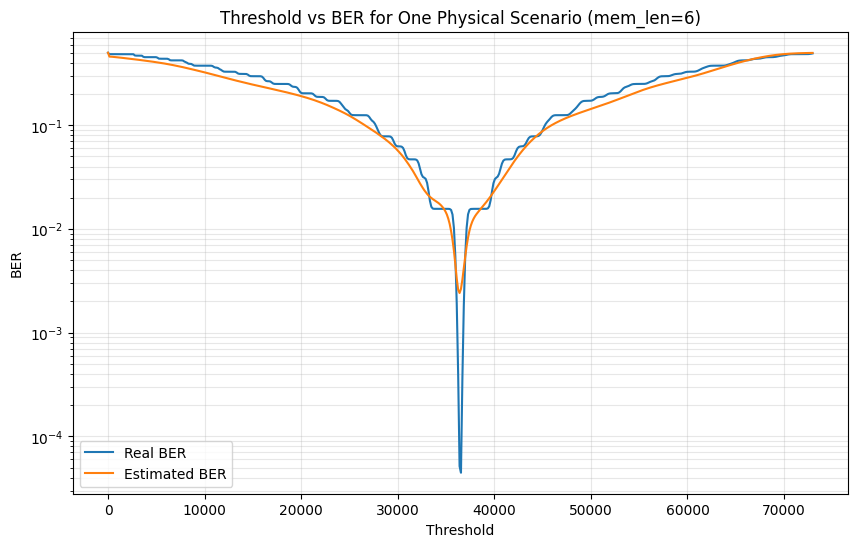

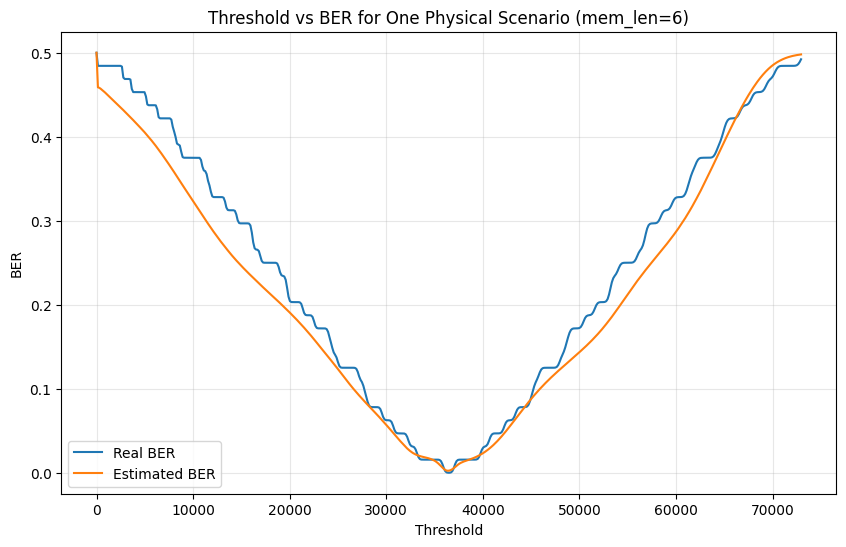

In [52]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_minsidez_best.pth"
SCALER_PATH = "ber_boundedloghalf_minsidez_scalers.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag, z0, z1, min_side_z]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(7, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype)
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:9, :]  # pos, abs, snr, first_flag, z0, z1, min_side_z

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)
    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    z0_ch = np.tile(z0_scaled, (1, L)).astype(np.float32)
    z1_ch = np.tile(z1_scaled, (1, L)).astype(np.float32)
    min_side_z_ch = np.tile(min_side_z_scaled, (1, L)).astype(np.float32)

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
            z0_ch,
            z1_ch,
            min_side_z_ch,
        ],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Generated physical scenario
radius    = 3.6485676254025527
distance  = 10.135731959475024
diffusion = 51.36802218605558
Ts        = 1.1933440649110825
N         = 388928
mem_len   = 6
P         = [0.0952836  0.04167955 0.02109599 0.01323983 0.00928885 0.00697681]
P_scaled  = [37058.46028454 16210.34416095  8204.82193215  5149.33902953
  3612.69537635  2713.47697434]
variances = [33527.39674923 15534.7043052   8031.73307524  5081.16267699
  3579.13757675  2694.54555955]
Threshold search interval: 0.0 to 72949.1377578628
sum(P_scaled) = 72949.1377578628
      threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0      0.000000  0.500000       0.500000  2.980232e-08     1.432099e-08
1    146.190657  0.484375       0.474613  9.762287e-03     8.842362e-03
2    292.381314  0.484375       0.472215  1.216024e-02     1.104216e-02
3    438.571970  0.484375       0.470628  1.374650e-02     1.250349e-02
4    584.762627  0.484375       0.469117  1.525822e-02     1.390074e-02
5    730.9

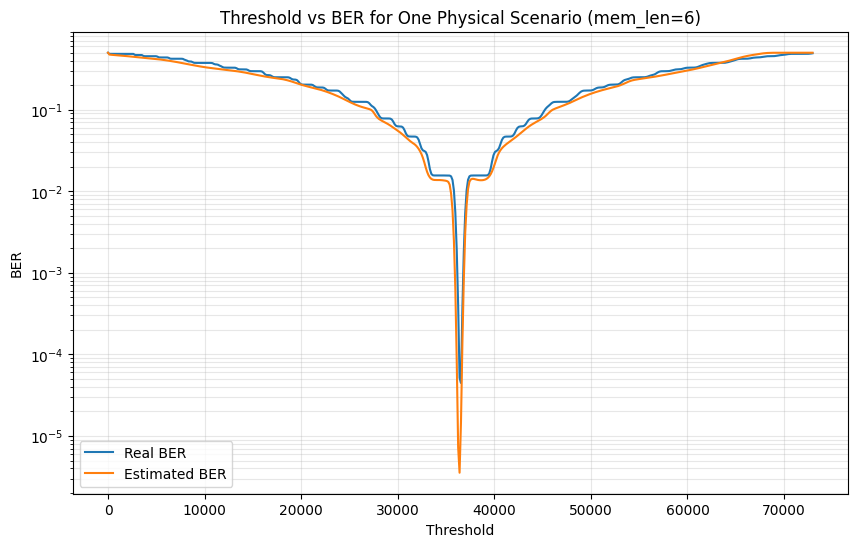

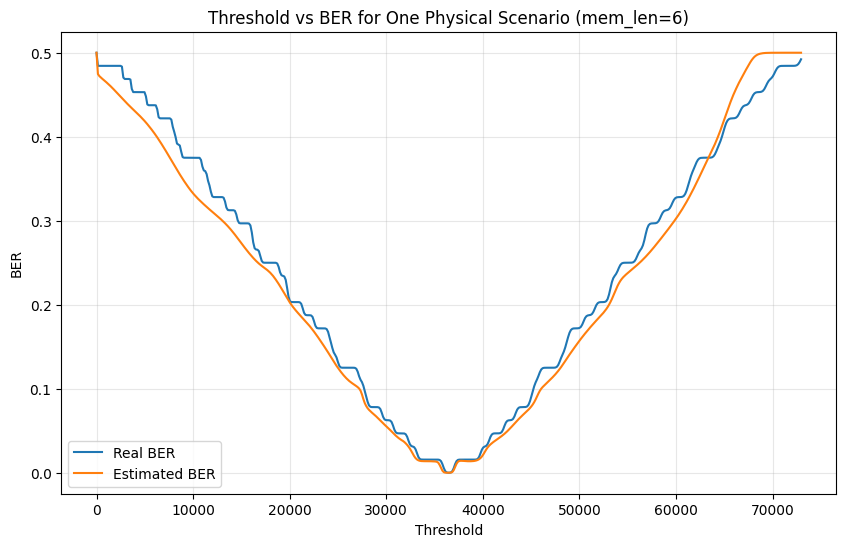

In [55]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_minsidez_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_minsidez_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains:
        # [normalized position, abs tap, snr proxy, first flag, z0, z1, min_side_z]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(7, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype)
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:9, :]  # pos, abs, snr, first_flag, z0, z1, min_side_z

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)
    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    z0_ch = np.tile(z0_scaled, (1, L)).astype(np.float32)
    z1_ch = np.tile(z1_scaled, (1, L)).astype(np.float32)
    min_side_z_ch = np.tile(min_side_z_scaled, (1, L)).astype(np.float32)

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
            z0_ch,
            z1_ch,
            min_side_z_ch,
        ],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [58]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_best.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_last.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=500000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-5
    )

    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.1948 | Val Loss: 0.1962 | Train RMSE(log10): 1.4291 (~26.86x) | Val RMSE(log10): 1.4341 (~27.17x) | Train MAE(log10): 0.5479 | Val MAE(log10): 0.5501 | Train MAE(raw): 0.047024 | Val MAE(raw): 0.047002
  -> New best model saved at epoch 1 with Val Loss: 0.196224
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0927 | Val Loss: 0.0906 | Train RMSE(log10): 0.8677 (~7.37x) | Val RMSE(log10): 0.8534 (~7.13x) | Train MAE(log10): 0.2919 | Val MAE(log10): 0.2872 | Train MAE(raw): 0.024258 | Val MAE(raw): 0.024084
  -> New best model saved at epoch 2 with Val Loss: 0.090644
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0732 | Val Loss: 0.0727 | Train RMSE(log10): 0.7176 (~5.22x) | Val RMSE(log10): 0.7076 (~5.10x) | Train MAE(log10): 0.2712 | Val MAE(log10): 0.2703 | Train MAE(raw): 0.041992 | Val MAE(raw): 0.041911
  -> New best model saved at epoch 3 with V

Epoch 033 | LR: 1.25e-05 | Train Loss: 0.0071 | Val Loss: 0.0072 | Train RMSE(log10): 0.1417 (~1.39x) | Val RMSE(log10): 0.1461 (~1.40x) | Train MAE(log10): 0.0848 | Val MAE(log10): 0.0851 | Train MAE(raw): 0.029131 | Val MAE(raw): 0.029177
  -> New best model saved at epoch 33 with Val Loss: 0.007200
Epoch 034 | LR: 1.25e-05 | Train Loss: 0.0080 | Val Loss: 0.0081 | Train RMSE(log10): 0.1492 (~1.41x) | Val RMSE(log10): 0.1516 (~1.42x) | Train MAE(log10): 0.0849 | Val MAE(log10): 0.0852 | Train MAE(raw): 0.027219 | Val MAE(raw): 0.027278
Epoch 035 | LR: 1.25e-05 | Train Loss: 0.0103 | Val Loss: 0.0104 | Train RMSE(log10): 0.1781 (~1.51x) | Val RMSE(log10): 0.1813 (~1.52x) | Train MAE(log10): 0.0936 | Val MAE(log10): 0.0940 | Train MAE(raw): 0.027650 | Val MAE(raw): 0.027697
Epoch 036 | LR: 1.25e-05 | Train Loss: 0.0113 | Val Loss: 0.0114 | Train RMSE(log10): 0.1842 (~1.53x) | Val RMSE(log10): 0.1856 (~1.53x) | Train MAE(log10): 0.0918 | Val MAE(log10): 0.0918 | Train MAE(raw): 0.026865

Epoch 066 | LR: 3.91e-07 | Train Loss: 0.0056 | Val Loss: 0.0058 | Train RMSE(log10): 0.1178 (~1.31x) | Val RMSE(log10): 0.1237 (~1.33x) | Train MAE(log10): 0.0848 | Val MAE(log10): 0.0854 | Train MAE(raw): 0.029965 | Val MAE(raw): 0.030019
Epoch 067 | LR: 1.95e-07 | Train Loss: 0.0058 | Val Loss: 0.0061 | Train RMSE(log10): 0.1194 (~1.32x) | Val RMSE(log10): 0.1253 (~1.33x) | Train MAE(log10): 0.0843 | Val MAE(log10): 0.0850 | Train MAE(raw): 0.028779 | Val MAE(raw): 0.028843
Epoch 068 | LR: 1.95e-07 | Train Loss: 0.0058 | Val Loss: 0.0061 | Train RMSE(log10): 0.1204 (~1.32x) | Val RMSE(log10): 0.1260 (~1.34x) | Train MAE(log10): 0.0833 | Val MAE(log10): 0.0840 | Train MAE(raw): 0.028714 | Val MAE(raw): 0.028770
Epoch 069 | LR: 1.95e-07 | Train Loss: 0.0056 | Val Loss: 0.0059 | Train RMSE(log10): 0.1190 (~1.32x) | Val RMSE(log10): 0.1243 (~1.33x) | Train MAE(log10): 0.0822 | Val MAE(log10): 0.0828 | Train MAE(raw): 0.028787 | Val MAE(raw): 0.028855
Epoch 070 | LR: 1.95e-07 | Train Los

Epoch 100 | LR: 1.22e-08 | Train Loss: 0.0057 | Val Loss: 0.0060 | Train RMSE(log10): 0.1192 (~1.32x) | Val RMSE(log10): 0.1248 (~1.33x) | Train MAE(log10): 0.0839 | Val MAE(log10): 0.0846 | Train MAE(raw): 0.029597 | Val MAE(raw): 0.029651
Last model saved to: ./ber_boundedloghalf_globalhmg_last.pth
Best model saved to: ./ber_boundedloghalf_globalhmg_best.pth
Test Loss: 0.0055 | Test RMSE(log10): 0.1235 | Test MAE(log10): 0.0810 | Typical multiplicative error: ~1.33x | Test RMSE(raw): 0.042458 | Test MAE(raw): 0.028288

Per-range test diagnostics:
low_BER(y<1e-6) | count=9585 | RMSE(log10)=0.1710 | MAE(log10)=0.0982 | factor~1.48x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=1541 | RMSE(log10)=0.3108 | MAE(log10)=0.1619 | factor~2.05x | RMSE(raw)=0.000128 | MAE(raw)=0.000057
high_BER(y>=1e-3) | count=37291 | RMSE(log10)=0.0910 | MAE(log10)=0.0733 | factor~1.23x | RMSE(raw)=0.048379 | MAE(raw)=0.036725
Scalers saved to: ./ber_boundedloghalf_globalhmg_scalers.p

In [59]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalhmg_scalers_5M.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)

    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(y>=1e-3)": targets_raw >= 1e-3,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH,
        batch_size=256,
        nrows=5000000,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-5
    )

    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(100):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0382 | Val Loss: 0.0385 | Train RMSE(log10): 0.4865 (~3.07x) | Val RMSE(log10): 0.4894 (~3.09x) | Train MAE(log10): 0.1603 | Val MAE(log10): 0.1609 | Train MAE(raw): 0.029605 | Val MAE(raw): 0.029597
  -> New best model saved at epoch 1 with Val Loss: 0.038458
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0296 | Val Loss: 0.0299 | Train RMSE(log10): 0.4068 (~2.55x) | Val RMSE(log10): 0.4112 (~2.58x) | Train MAE(log10): 0.1462 | Val MAE(log10): 0.1469 | Train MAE(raw): 0.033071 | Val MAE(raw): 0.033050
  -> New best model saved at epoch 2 with Val Loss: 0.029931
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0256 | Val Loss: 0.0257 | Train RMSE(log10): 0.3600 (~2.29x) | Val RMSE(log10): 0.3609 (~2.30x) | Train MAE(log10): 0.1523 | Val MAE(log10): 0.1524 | Train MAE(raw): 0.038684 | Val MAE(raw): 0.038693
  -> New best model saved at epoch 3 with Val

Epoch 032 | LR: 5.00e-05 | Train Loss: 0.0014 | Val Loss: 0.0014 | Train RMSE(log10): 0.0575 (~1.14x) | Val RMSE(log10): 0.0573 (~1.14x) | Train MAE(log10): 0.0256 | Val MAE(log10): 0.0255 | Train MAE(raw): 0.005845 | Val MAE(raw): 0.005835
  -> New best model saved at epoch 32 with Val Loss: 0.001387
Epoch 033 | LR: 5.00e-05 | Train Loss: 0.0080 | Val Loss: 0.0080 | Train RMSE(log10): 0.1381 (~1.37x) | Val RMSE(log10): 0.1384 (~1.38x) | Train MAE(log10): 0.0507 | Val MAE(log10): 0.0508 | Train MAE(raw): 0.005888 | Val MAE(raw): 0.005884
Epoch 034 | LR: 5.00e-05 | Train Loss: 0.0025 | Val Loss: 0.0025 | Train RMSE(log10): 0.0761 (~1.19x) | Val RMSE(log10): 0.0769 (~1.19x) | Train MAE(log10): 0.0326 | Val MAE(log10): 0.0327 | Train MAE(raw): 0.006151 | Val MAE(raw): 0.006142
Epoch 035 | LR: 5.00e-05 | Train Loss: 0.0071 | Val Loss: 0.0071 | Train RMSE(log10): 0.1313 (~1.35x) | Val RMSE(log10): 0.1313 (~1.35x) | Train MAE(log10): 0.0509 | Val MAE(log10): 0.0509 | Train MAE(raw): 0.006469

Epoch 065 | LR: 3.13e-06 | Train Loss: 0.0008 | Val Loss: 0.0008 | Train RMSE(log10): 0.0410 (~1.10x) | Val RMSE(log10): 0.0410 (~1.10x) | Train MAE(log10): 0.0216 | Val MAE(log10): 0.0216 | Train MAE(raw): 0.005297 | Val MAE(raw): 0.005291
Epoch 066 | LR: 3.13e-06 | Train Loss: 0.0005 | Val Loss: 0.0005 | Train RMSE(log10): 0.0335 (~1.08x) | Val RMSE(log10): 0.0335 (~1.08x) | Train MAE(log10): 0.0191 | Val MAE(log10): 0.0191 | Train MAE(raw): 0.004973 | Val MAE(raw): 0.004967
  -> New best model saved at epoch 66 with Val Loss: 0.000508
Epoch 067 | LR: 3.13e-06 | Train Loss: 0.0016 | Val Loss: 0.0016 | Train RMSE(log10): 0.0595 (~1.15x) | Val RMSE(log10): 0.0595 (~1.15x) | Train MAE(log10): 0.0268 | Val MAE(log10): 0.0268 | Train MAE(raw): 0.005013 | Val MAE(raw): 0.005006
Epoch 068 | LR: 3.13e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0394 (~1.09x) | Val RMSE(log10): 0.0394 (~1.10x) | Train MAE(log10): 0.0201 | Val MAE(log10): 0.0201 | Train MAE(raw): 0.004983

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.494217  5.720186e-03  

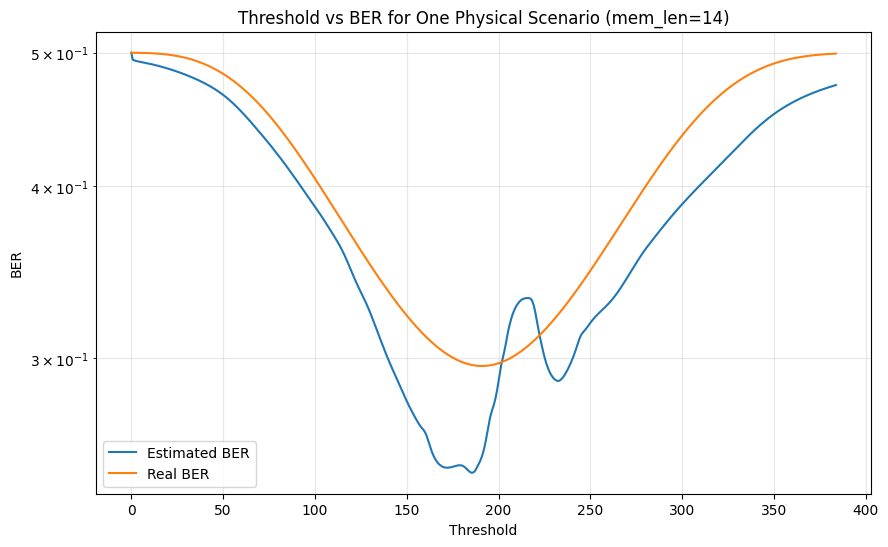

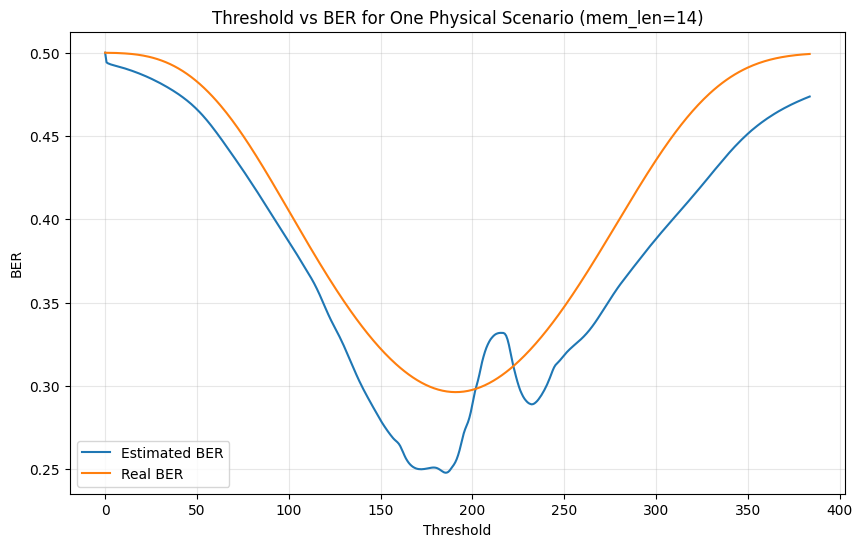

In [63]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [64]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_best_v2.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_last_v2.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_v2.pkl"
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
    - model outputs unconstrained raw scalar u
    - u is mapped to: pred_log = log10(0.5) - softplus(u)
    - pred_raw = 10 ** pred_log
    - Huber loss in log10(BER) space
    - Huber loss in raw BER space
    - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
    0 -> scaled tap means multiplied by number of molecules
    1 -> tap variances
    2 -> normalized position
    3 -> abs(scaled tap means)
    4 -> raw-ish log SNR proxy
    5 -> first-position indicator

    Global scalar features:
    0 -> z0 decision margin
    1 -> z1 decision margin
    2 -> min_side_z
    3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        X_thr, y_log, **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_thr, temp_y_log, **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 4,
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean",
            "snr_proxy_log", "first_flag",
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=500000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(), lr=1e-4, weight_decay=1e-5
    )
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.1479 | Val Loss: 0.1433 | Train RMSE(log10): 1.2325 (~17.08x) | Val RMSE(log10): 1.1980 (~15.78x) | Train MAE(log10): 0.4244 | Val MAE(log10): 0.4141 | Train MAE(raw): 0.034232 | Val MAE(raw): 0.034114
 -> New best model saved at epoch 1 with Val Loss: 0.143265
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0692 | Val Loss: 0.0676 | Train RMSE(log10): 0.7332 (~5.41x) | Val RMSE(log10): 0.7186 (~5.23x) | Train MAE(log10): 0.2509 | Val MAE(log10): 0.2469 | Train MAE(raw): 0.027648 | Val MAE(raw): 0.027473
 -> New best model saved at epoch 2 with Val Loss: 0.067564
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0608 | Val Loss: 0.0593 | Train RMSE(log10): 0.6853 (~4.84x) | Val RMSE(log10): 0.6724 (~4.70x) | Train MAE(log10): 0.2113 | Val MAE(log10): 0.2080 | Train MAE(raw): 0.019823 | Val MAE(raw): 0.019723
 -> New best model saved at epoch 3 with Val 

Epoch 032 | LR: 2.50e-05 | Train Loss: 0.0100 | Val Loss: 0.0099 | Train RMSE(log10): 0.1829 (~1.52x) | Val RMSE(log10): 0.1837 (~1.53x) | Train MAE(log10): 0.0937 | Val MAE(log10): 0.0937 | Train MAE(raw): 0.027523 | Val MAE(raw): 0.027614
Epoch 033 | LR: 2.50e-05 | Train Loss: 0.0099 | Val Loss: 0.0100 | Train RMSE(log10): 0.1670 (~1.47x) | Val RMSE(log10): 0.1686 (~1.47x) | Train MAE(log10): 0.0967 | Val MAE(log10): 0.0971 | Train MAE(raw): 0.026436 | Val MAE(raw): 0.026529
Epoch 034 | LR: 2.50e-05 | Train Loss: 0.0103 | Val Loss: 0.0101 | Train RMSE(log10): 0.1948 (~1.57x) | Val RMSE(log10): 0.1920 (~1.56x) | Train MAE(log10): 0.1005 | Val MAE(log10): 0.1004 | Train MAE(raw): 0.027023 | Val MAE(raw): 0.027109
Epoch 035 | LR: 1.25e-05 | Train Loss: 0.0143 | Val Loss: 0.0139 | Train RMSE(log10): 0.2300 (~1.70x) | Val RMSE(log10): 0.2222 (~1.67x) | Train MAE(log10): 0.1076 | Val MAE(log10): 0.1068 | Train MAE(raw): 0.028476 | Val MAE(raw): 0.028567
Epoch 036 | LR: 1.25e-05 | Train Los

Epoch 066 | LR: 3.91e-07 | Train Loss: 0.0077 | Val Loss: 0.0078 | Train RMSE(log10): 0.1459 (~1.40x) | Val RMSE(log10): 0.1497 (~1.41x) | Train MAE(log10): 0.0900 | Val MAE(log10): 0.0902 | Train MAE(raw): 0.026786 | Val MAE(raw): 0.026877
Epoch 067 | LR: 3.91e-07 | Train Loss: 0.0077 | Val Loss: 0.0077 | Train RMSE(log10): 0.1493 (~1.41x) | Val RMSE(log10): 0.1518 (~1.42x) | Train MAE(log10): 0.0900 | Val MAE(log10): 0.0901 | Train MAE(raw): 0.026216 | Val MAE(raw): 0.026306
Epoch 068 | LR: 1.95e-07 | Train Loss: 0.0090 | Val Loss: 0.0089 | Train RMSE(log10): 0.1757 (~1.50x) | Val RMSE(log10): 0.1769 (~1.50x) | Train MAE(log10): 0.0924 | Val MAE(log10): 0.0924 | Train MAE(raw): 0.027319 | Val MAE(raw): 0.027401
Epoch 069 | LR: 1.95e-07 | Train Loss: 0.0084 | Val Loss: 0.0084 | Train RMSE(log10): 0.1532 (~1.42x) | Val RMSE(log10): 0.1557 (~1.43x) | Train MAE(log10): 0.0941 | Val MAE(log10): 0.0943 | Train MAE(raw): 0.027130 | Val MAE(raw): 0.027226
Epoch 070 | LR: 1.95e-07 | Train Los

In [65]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_best_v2_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_last_v2_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
    - model outputs unconstrained raw scalar u
    - u is mapped to: pred_log = log10(0.5) - softplus(u)
    - pred_raw = 10 ** pred_log
    - Huber loss in log10(BER) space
    - Huber loss in raw BER space
    - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
    0 -> scaled tap means multiplied by number of molecules
    1 -> tap variances
    2 -> normalized position
    3 -> abs(scaled tap means)
    4 -> raw-ish log SNR proxy
    5 -> first-position indicator

    Global scalar features:
    0 -> z0 decision margin
    1 -> z1 decision margin
    2 -> min_side_z
    3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        X_thr, y_log, **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_thr, temp_y_log, **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 4,
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean",
            "snr_proxy_log", "first_flag",
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=5000000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(), lr=1e-4, weight_decay=1e-5
    )
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.9,
        beta_raw=0.1,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0447 | Val Loss: 0.0450 | Train RMSE(log10): 0.5380 (~3.45x) | Val RMSE(log10): 0.5411 (~3.48x) | Train MAE(log10): 0.1745 | Val MAE(log10): 0.1750 | Train MAE(raw): 0.028048 | Val MAE(raw): 0.028048
 -> New best model saved at epoch 1 with Val Loss: 0.044987
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0233 | Val Loss: 0.0233 | Train RMSE(log10): 0.3183 (~2.08x) | Val RMSE(log10): 0.3180 (~2.08x) | Train MAE(log10): 0.1396 | Val MAE(log10): 0.1397 | Train MAE(raw): 0.041299 | Val MAE(raw): 0.041270
 -> New best model saved at epoch 2 with Val Loss: 0.023337
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0219 | Val Loss: 0.0223 | Train RMSE(log10): 0.3599 (~2.29x) | Val RMSE(log10): 0.3642 (~2.31x) | Train MAE(log10): 0.1308 | Val MAE(log10): 0.1317 | Train MAE(raw): 0.040048 | Val MAE(raw): 0.040022
 -> New best model saved at epoch 3 with Val Lo

Epoch 032 | LR: 5.00e-05 | Train Loss: 0.0034 | Val Loss: 0.0034 | Train RMSE(log10): 0.0946 (~1.24x) | Val RMSE(log10): 0.0954 (~1.25x) | Train MAE(log10): 0.0364 | Val MAE(log10): 0.0366 | Train MAE(raw): 0.007799 | Val MAE(raw): 0.007804
Epoch 033 | LR: 5.00e-05 | Train Loss: 0.0023 | Val Loss: 0.0023 | Train RMSE(log10): 0.0838 (~1.21x) | Val RMSE(log10): 0.0844 (~1.21x) | Train MAE(log10): 0.0321 | Val MAE(log10): 0.0322 | Train MAE(raw): 0.007106 | Val MAE(raw): 0.007101
 -> New best model saved at epoch 33 with Val Loss: 0.002300
Epoch 034 | LR: 5.00e-05 | Train Loss: 0.0024 | Val Loss: 0.0024 | Train RMSE(log10): 0.0833 (~1.21x) | Val RMSE(log10): 0.0842 (~1.21x) | Train MAE(log10): 0.0293 | Val MAE(log10): 0.0294 | Train MAE(raw): 0.005919 | Val MAE(raw): 0.005916
Epoch 035 | LR: 5.00e-05 | Train Loss: 0.0036 | Val Loss: 0.0037 | Train RMSE(log10): 0.1042 (~1.27x) | Val RMSE(log10): 0.1042 (~1.27x) | Train MAE(log10): 0.0367 | Val MAE(log10): 0.0368 | Train MAE(raw): 0.007203 

Epoch 065 | LR: 6.25e-06 | Train Loss: 0.0012 | Val Loss: 0.0012 | Train RMSE(log10): 0.0521 (~1.13x) | Val RMSE(log10): 0.0524 (~1.13x) | Train MAE(log10): 0.0252 | Val MAE(log10): 0.0253 | Train MAE(raw): 0.006080 | Val MAE(raw): 0.006077
Epoch 066 | LR: 6.25e-06 | Train Loss: 0.0014 | Val Loss: 0.0014 | Train RMSE(log10): 0.0565 (~1.14x) | Val RMSE(log10): 0.0569 (~1.14x) | Train MAE(log10): 0.0270 | Val MAE(log10): 0.0270 | Train MAE(raw): 0.006086 | Val MAE(raw): 0.006083
Epoch 067 | LR: 3.13e-06 | Train Loss: 0.0011 | Val Loss: 0.0011 | Train RMSE(log10): 0.0492 (~1.12x) | Val RMSE(log10): 0.0497 (~1.12x) | Train MAE(log10): 0.0241 | Val MAE(log10): 0.0242 | Train MAE(raw): 0.006697 | Val MAE(raw): 0.006693
Epoch 068 | LR: 3.13e-06 | Train Loss: 0.0012 | Val Loss: 0.0012 | Train RMSE(log10): 0.0527 (~1.13x) | Val RMSE(log10): 0.0530 (~1.13x) | Train MAE(log10): 0.0257 | Val MAE(log10): 0.0257 | Train MAE(raw): 0.006606 | Val MAE(raw): 0.006604
Epoch 069 | LR: 3.13e-06 | Train Los

In [ ]:
Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0576 | MAE(log10)=0.0237 | factor~1.14x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.1268 | MAE(log10)=0.1131 | factor~1.34x | RMSE(raw)=0.000095 | MAE(raw)=0.000046
high_BER(1e-3<=y<0.10) | count=60956 | RMSE(log10)=0.0461 | MAE(log10)=0.0288 | factor~1.11x | RMSE(raw)=0.002569 | MAE(raw)=0.001799
extreme_BER(y>=0.10) | count=311183 | RMSE(log10)=0.0212 | MAE(log10)=0.0161 | factor~1.05x | RMSE(raw)=0.012468 | MAE(raw)=0.009624
Scalers saved to: ./ber_boundedloghalf_globalboth_scalers_v2_5M.pkl

In [ ]:
Test Loss: 0.0005 | Test RMSE(log10): 0.0337 | Test MAE(log10): 0.0191 | Typical multiplicative error: ~1.08x | Test RMSE(raw): 0.008501 | Test MAE(raw): 0.004985

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0379 | MAE(log10)=0.0220 | factor~1.09x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.1157 | MAE(log10)=0.1070 | factor~1.31x | RMSE(raw)=0.000077 | MAE(raw)=0.000044
high_BER(y>=1e-3) | count=372139 | RMSE(log10)=0.0233 | MAE(log10)=0.0147 | factor~1.06x | RMSE(raw)=0.009697 | MAE(raw)=0.006484

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.499997  6.009397e-05  

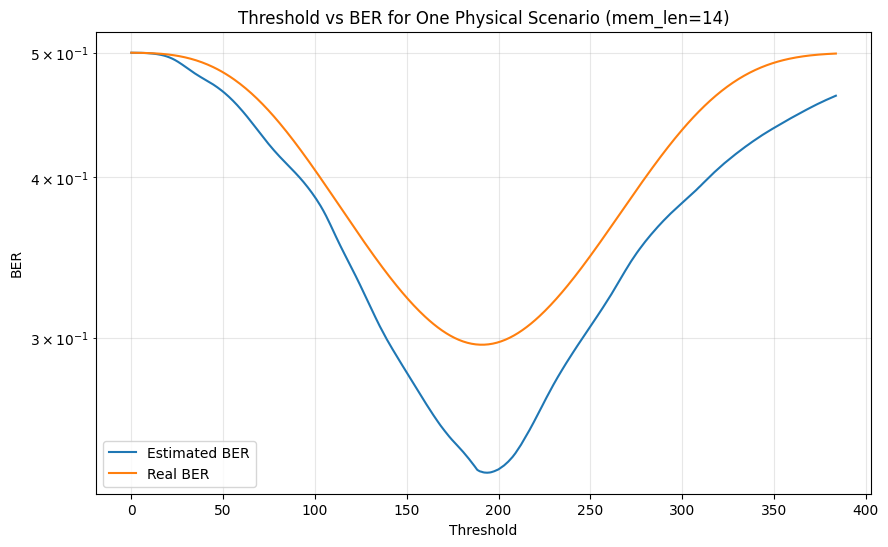

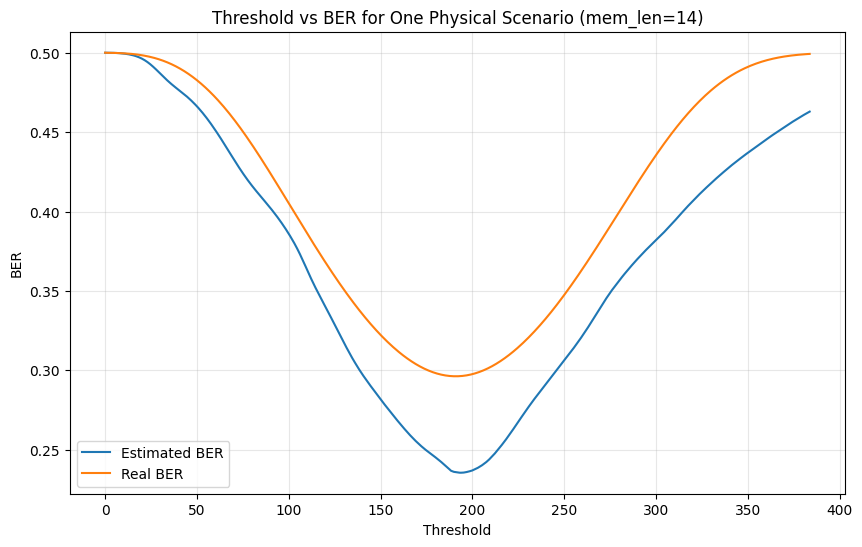

In [74]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalboth_best_v2_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> min_side_z
      3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    # Updated to include all 4 global features
    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, min_side_z_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]

# Updated global_dim fallback to 4 based on training script
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 4), 
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [68]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model: Load the best pre-trained model to start
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_best_v2_5M.pth"
)

# Output paths for the fine-tuned model (v6 - Unfrozen)
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_v2plus_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_v2plus_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
    - model outputs unconstrained raw scalar u
    - u is mapped to: pred_log = log10(0.5) - softplus(u)
    - pred_raw = 10 ** pred_log
    - Huber loss in log10(BER) space
    - Huber loss in raw BER space
    - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,     # Set to 0.5 for quadratic penalty in raw space
        alpha_log=0.3,     # Favor raw space
        beta_raw=0.7,      # Favor raw space
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit extreme threshold
        w_low=0.5,
        w_mid=1.5,
        w_high=3.0,
        w_ext=10.0,        # Massive penalty for missing extreme BER
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            # Default to extreme weights
            weights = torch.full_like(target_raw, self.w_ext)
            
            # Cascade down tiers
            weights = torch.where(
                target_raw < self.ext_thr, torch.full_like(weights, self.w_high), weights
            )
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
    0 -> scaled tap means multiplied by number of molecules
    1 -> tap variances
    2 -> normalized position
    3 -> abs(scaled tap means)
    4 -> raw-ish log SNR proxy
    5 -> first-position indicator

    Global scalar features:
    0 -> z0 decision margin
    1 -> z1 decision margin
    2 -> min_side_z
    3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # Final layer (zero weight decay applied during fine-tuning)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        X_thr, y_log, **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_thr, temp_y_log, **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    
    # ---------------------------------------------------------
    # WEIGHTED RANDOM SAMPLER FOR HIGH-BER FOCUS
    # ---------------------------------------------------------
    # Convert log target back to raw BER space to determine weight brackets
    t_y_raw_for_weights = np.clip(10 ** t_y_log, EPS, 0.5).reshape(-1)
    
    # Assign higher sample probabilities to higher BER regimes
    sample_weights = np.ones_like(t_y_raw_for_weights)
    sample_weights[t_y_raw_for_weights >= 0.10] = 5.0           # Extreme BER
    sample_weights[(t_y_raw_for_weights >= 1e-3) & (t_y_raw_for_weights < 0.10)] = 3.0  # High BER
    sample_weights[(t_y_raw_for_weights >= 1e-4) & (t_y_raw_for_weights < 1e-3)] = 1.0  # Mid BER
    sample_weights[t_y_raw_for_weights < 1e-4] = 0.5            # Low BER

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    # Note: shuffle must be omitted (defaults to False) when sampler is provided
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 4,
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean",
            "snr_proxy_log", "first_flag",
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=5000000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # UNFROZEN FINE-TUNING INITIALIZATION
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        print("Unfreezing the entire network to allow free learning, relying on the robust dataset to preserve geometry...")
        # Ensure everything requires grad (default behavior, but explicit here)
        for param in model.parameters():
            param.requires_grad = True
    else:
        print("Pre-trained model not found. Training from scratch...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    head_final_params = list(model.head[-1].parameters())
    trainable_base_params = [
        p for n, p in model.named_parameters() 
        if p.requires_grad and not n.startswith('head.8')
    ]

    # Keep LR strictly at 1e-5 since the CNN is completely unfrozen!
    optimizer = optim.AdamW([
        {'params': trainable_base_params, 'weight_decay': 1e-5},
        {'params': head_final_params, 'weight_decay': 0.0}  # Allow target asymptote approach
    ], lr=1e-5 if os.path.exists(PRETRAINED_MODEL_PATH) else 1e-4)

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4-Tier)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     # Set to 0.5 to force quadratic MSE-like penalty
        alpha_log=0.3,     # Shift focus heavily away from log deep tails
        beta_raw=0.7,      # Care primarily about absolute BER differences
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit boundary for extreme BER
        w_low=0.5,         # Forgive deep tail errors
        w_mid=1.5,         
        w_high=3.0,        
        w_ext=10.0,        # Massive penalty for missing the > 0.10 region
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalboth_best_v2_5M.pth for fine-tuning...
Unfreezing the entire network to allow free learning, relying on the robust dataset to preserve geometry...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-05 | Train Loss: 0.0011 | Val Loss: 0.0010 | Train RMSE(log10): 0.0308 (~1.07x) | Val RMSE(log10): 0.0479 (~1.12x) | Train MAE(log10): 0.0182 | Val MAE(log10): 0.0238 | Train MAE(raw): 0.007952 | Val MAE(raw): 0.005993
 -> New best model saved at epoch 1 with Val Loss: 0.000999
Epoch 002 | LR: 1.00e-05 | Train Loss: 0.0011 | Val Loss: 0.0009 | Train RMSE(log10): 0.0285 (~1.07x) | Val RMSE(log10): 0.0437 (~1.11x) | Train MAE(log10): 0.0177 | Val MAE(log10): 0.0219 | Train MAE(raw): 0.008235 | Val MAE(raw): 0.006196
 -> New best model saved at epoch 2 with Val Loss: 0.000941
Epoch 003 | LR: 1.00e-05 | Train Loss: 0.0010 | Val Loss: 0.0011 | Train RMSE(log10

Epoch 032 | LR: 2.50e-06 | Train Loss: 0.0008 | Val Loss: 0.0007 | Train RMSE(log10): 0.0242 (~1.06x) | Val RMSE(log10): 0.0382 (~1.09x) | Train MAE(log10): 0.0149 | Val MAE(log10): 0.0194 | Train MAE(raw): 0.007168 | Val MAE(raw): 0.005383
Epoch 033 | LR: 2.50e-06 | Train Loss: 0.0007 | Val Loss: 0.0006 | Train RMSE(log10): 0.0229 (~1.05x) | Val RMSE(log10): 0.0382 (~1.09x) | Train MAE(log10): 0.0139 | Val MAE(log10): 0.0183 | Train MAE(raw): 0.006753 | Val MAE(raw): 0.005076
 -> New best model saved at epoch 33 with Val Loss: 0.000619
Epoch 034 | LR: 2.50e-06 | Train Loss: 0.0007 | Val Loss: 0.0008 | Train RMSE(log10): 0.0292 (~1.07x) | Val RMSE(log10): 0.0523 (~1.13x) | Train MAE(log10): 0.0151 | Val MAE(log10): 0.0223 | Train MAE(raw): 0.006556 | Val MAE(raw): 0.004936
Epoch 035 | LR: 2.50e-06 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0238 (~1.06x) | Val RMSE(log10): 0.0386 (~1.09x) | Train MAE(log10): 0.0147 | Val MAE(log10): 0.0189 | Train MAE(raw): 0.007132 

Epoch 065 | LR: 1.56e-07 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0264 (~1.06x) | Val RMSE(log10): 0.0469 (~1.11x) | Train MAE(log10): 0.0144 | Val MAE(log10): 0.0199 | Train MAE(raw): 0.006699 | Val MAE(raw): 0.005036
Epoch 066 | LR: 7.81e-08 | Train Loss: 0.0006 | Val Loss: 0.0006 | Train RMSE(log10): 0.0240 (~1.06x) | Val RMSE(log10): 0.0410 (~1.10x) | Train MAE(log10): 0.0139 | Val MAE(log10): 0.0187 | Train MAE(raw): 0.006509 | Val MAE(raw): 0.004895
Epoch 067 | LR: 7.81e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0259 (~1.06x) | Val RMSE(log10): 0.0451 (~1.11x) | Train MAE(log10): 0.0144 | Val MAE(log10): 0.0201 | Train MAE(raw): 0.006554 | Val MAE(raw): 0.004926
Epoch 068 | LR: 7.81e-08 | Train Loss: 0.0007 | Val Loss: 0.0007 | Train RMSE(log10): 0.0258 (~1.06x) | Val RMSE(log10): 0.0446 (~1.11x) | Train MAE(log10): 0.0143 | Val MAE(log10): 0.0198 | Train MAE(raw): 0.006572 | Val MAE(raw): 0.004945
Epoch 069 | LR: 7.81e-08 | Train Los

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.499983  4.569945e-05  

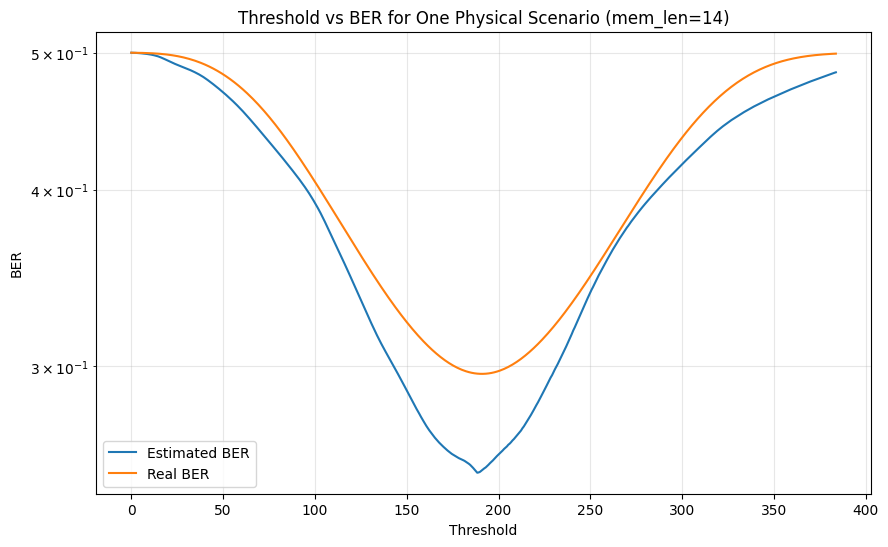

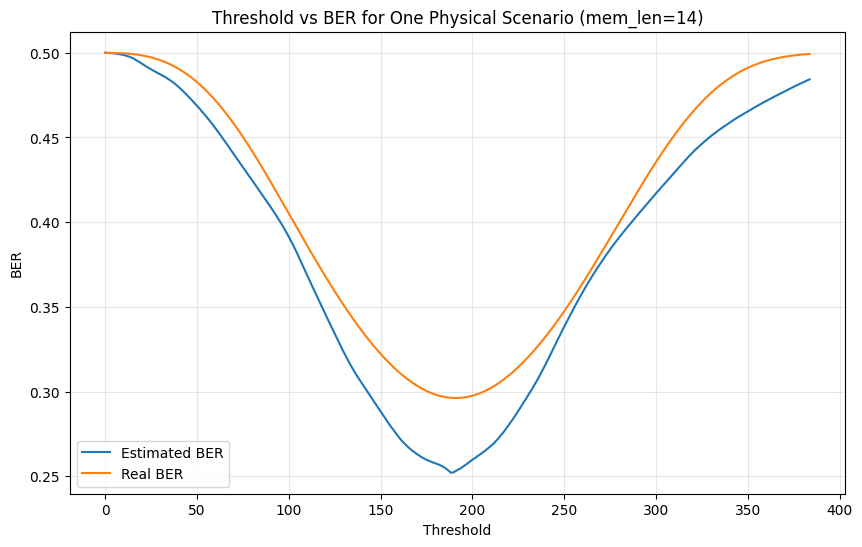

In [73]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalboth_finetuned_v2plus_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> min_side_z
      3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    # Updated to include all 4 global features
    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, min_side_z_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]

# Updated global_dim fallback to 4 based on training script
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 4), 
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
Summary
Mean abs raw error   : 0.02074623106677
Mean abs log10 error : 0.02559106878544937
Max  abs log10 error : 0.07013701607548539

Best threshold from real BER      : 190.70032988848362
Minimum real BER                  : 0.2962519915928659
Best threshold from estimated BER : 188.39347105918745
Estimated BER at that threshold   : 0.25216344

In [ ]:
Summary
Mean abs raw error   : 0.03799593610042139
Mean abs log10 error : 0.046744066200743326
Max  abs log10 error : 0.09989710255080464

Best threshold from real BER      : 190.70032988848362
Minimum real BER                  : 0.2962519915928659
Best threshold from estimated BER : 193.77614166087852
Estimated BER at that threshold   : 0.23551911

In [75]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Input model: Load the v2plus model
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_v2plus_best_5M.pth"
)

# Output paths for the fine-tuned model (v2plusplus)
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_finetuned_v2plusplus_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
    - model outputs unconstrained raw scalar u
    - u is mapped to: pred_log = log10(0.5) - softplus(u)
    - pred_raw = 10 ** pred_log
    - Huber loss in log10(BER) space
    - Huber loss in raw BER space
    - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,     # Set to 0.5 for quadratic penalty in raw space
        alpha_log=0.3,     # Favor raw space
        beta_raw=0.7,      # Favor raw space
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      # Explicit extreme threshold
        w_low=0.5,
        w_mid=2.5,         # Increased to drag the mid_BER error down
        w_high=3.0,
        w_ext=8.0,         # Softened from 10.0 to balance the composite sampler
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            # Default to extreme weights
            weights = torch.full_like(target_raw, self.w_ext)
            
            # Cascade down tiers
            weights = torch.where(
                target_raw < self.ext_thr, torch.full_like(weights, self.w_high), weights
            )
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
    0 -> scaled tap means multiplied by number of molecules
    1 -> tap variances
    2 -> normalized position
    3 -> abs(scaled tap means)
    4 -> raw-ish log SNR proxy
    5 -> first-position indicator

    Global scalar features:
    0 -> z0 decision margin
    1 -> z1 decision margin
    2 -> min_side_z
    3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # Final layer (zero weight decay applied during fine-tuning)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)
    
    # Extract mem_len array for the sampler
    mem_len_raw = df["mem_len"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_mem_len, temp_mem_len
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        X_thr, y_log, mem_len_raw, **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_mem_len, te_mem_len
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_thr, temp_y_log, temp_mem_len, **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    
    # ---------------------------------------------------------
    # COMPOSITE WEIGHTED RANDOM SAMPLER (mem_len + BER)
    # ---------------------------------------------------------
    t_y_raw_for_weights = np.clip(10 ** t_y_log, EPS, 0.5).reshape(-1)
    t_mem_len_flat = t_mem_len.reshape(-1)
    
    # 1. Base weights for BER regimes
    ber_weights = np.ones_like(t_y_raw_for_weights)
    ber_weights[t_y_raw_for_weights >= 0.10] = 5.0           # Extreme BER
    ber_weights[(t_y_raw_for_weights >= 1e-3) & (t_y_raw_for_weights < 0.10)] = 3.0  # High BER
    ber_weights[(t_y_raw_for_weights >= 1e-4) & (t_y_raw_for_weights < 1e-3)] = 2.0  # Mid BER (Bumped to fix 1.29x error)
    ber_weights[t_y_raw_for_weights < 1e-4] = 0.5            # Low BER

    # 2. Base weights for mem_len (50/50 probability distribution constraint)
    mem_weights = np.ones_like(t_mem_len_flat, dtype=np.float64)
    mask_lt_8 = t_mem_len_flat < 8
    mask_ge_8 = t_mem_len_flat >= 8

    count_lt_8 = mask_lt_8.sum()
    count_ge_8 = mask_ge_8.sum()

    if count_lt_8 > 0:
        mem_weights[mask_lt_8] = 1.0 / count_lt_8
    if count_ge_8 > 0:
        mem_weights[mask_ge_8] = 1.0 / count_ge_8
        
    # Normalize mem_weights to not crush BER multipliers
    mem_weights = mem_weights / mem_weights.mean()

    # 3. Composite Multiplication
    final_sample_weights = ber_weights * mem_weights

    sampler = WeightedRandomSampler(
        weights=final_sample_weights,
        num_samples=len(final_sample_weights),
        replacement=True
    )

    # Note: shuffle must be omitted (defaults to False) when sampler is provided
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 4,
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean",
            "snr_proxy_log", "first_flag",
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=5000000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    # ---------------------------------------------------------
    # UNFROZEN FINE-TUNING INITIALIZATION
    # ---------------------------------------------------------
    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        print("Unfreezing the entire network to allow free learning, relying on the robust dataset to preserve geometry...")
        for param in model.parameters():
            param.requires_grad = True
    else:
        print("Pre-trained model not found. Training from scratch...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    head_final_params = list(model.head[-1].parameters())
    trainable_base_params = [
        p for n, p in model.named_parameters() 
        if p.requires_grad and not n.startswith('head.8')
    ]

    optimizer = optim.AdamW([
        {'params': trainable_base_params, 'weight_decay': 1e-5},
        {'params': head_final_params, 'weight_decay': 0.0}  
    ], lr=1e-5 if os.path.exists(PRETRAINED_MODEL_PATH) else 1e-4)

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4-Tier)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     
        alpha_log=0.3,     
        beta_raw=0.7,      
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      
        w_low=0.5,         
        w_mid=2.5,         # Increased from 1.5 to pull down the 1.29x mid_BER error
        w_high=3.0,        
        w_ext=8.0,         # Softened from 10.0 to balance the composite sampler
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Loading pre-trained model from ./ber_boundedloghalf_globalboth_finetuned_v2plus_best_5M.pth for fine-tuning...
Unfreezing the entire network to allow free learning, relying on the robust dataset to preserve geometry...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-05 | Train Loss: 0.0008 | Val Loss: 0.0007 | Train RMSE(log10): 0.0248 (~1.06x) | Val RMSE(log10): 0.0524 (~1.13x) | Train MAE(log10): 0.0157 | Val MAE(log10): 0.0208 | Train MAE(raw): 0.009298 | Val MAE(raw): 0.005269
 -> New best model saved at epoch 1 with Val Loss: 0.000727
Epoch 002 | LR: 1.00e-05 | Train Loss: 0.0007 | Val Loss: 0.0006 | Train RMSE(log10): 0.0215 (~1.05x) | Val RMSE(log10): 0.0451 (~1.11x) | Train MAE(log10): 0.0143 | Val MAE(log10): 0.0184 | Train MAE(raw): 0.008635 | Val MAE(raw): 0.004925
 -> New best model saved at epoch 2 with Val Loss: 0.000583
Epoch 003 | LR: 1.00e-05 | Train Loss: 0.0007 | Val Loss: 0.0007 | Tr

Epoch 033 | LR: 6.25e-07 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0201 (~1.05x) | Val RMSE(log10): 0.0385 (~1.09x) | Train MAE(log10): 0.0141 | Val MAE(log10): 0.0179 | Train MAE(raw): 0.008479 | Val MAE(raw): 0.004733
Epoch 034 | LR: 3.13e-07 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0196 (~1.05x) | Val RMSE(log10): 0.0350 (~1.08x) | Train MAE(log10): 0.0141 | Val MAE(log10): 0.0169 | Train MAE(raw): 0.008595 | Val MAE(raw): 0.004785
Epoch 035 | LR: 3.13e-07 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0199 (~1.05x) | Val RMSE(log10): 0.0368 (~1.09x) | Train MAE(log10): 0.0140 | Val MAE(log10): 0.0177 | Train MAE(raw): 0.008466 | Val MAE(raw): 0.004732
Epoch 036 | LR: 3.13e-07 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0206 (~1.05x) | Val RMSE(log10): 0.0384 (~1.09x) | Train MAE(log10): 0.0143 | Val MAE(log10): 0.0183 | Train MAE(raw): 0.008523 | Val MAE(raw): 0.004753
Epoch 037 | LR: 3.13e-07 | Train Los

Epoch 067 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0204 (~1.05x) | Val RMSE(log10): 0.0388 (~1.09x) | Train MAE(log10): 0.0141 | Val MAE(log10): 0.0180 | Train MAE(raw): 0.008433 | Val MAE(raw): 0.004697
Epoch 068 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0189 (~1.04x) | Val RMSE(log10): 0.0332 (~1.08x) | Train MAE(log10): 0.0138 | Val MAE(log10): 0.0165 | Train MAE(raw): 0.008455 | Val MAE(raw): 0.004716
Epoch 069 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0204 (~1.05x) | Val RMSE(log10): 0.0379 (~1.09x) | Train MAE(log10): 0.0142 | Val MAE(log10): 0.0180 | Train MAE(raw): 0.008458 | Val MAE(raw): 0.004689
Epoch 070 | LR: 1.95e-08 | Train Loss: 0.0006 | Val Loss: 0.0005 | Train RMSE(log10): 0.0191 (~1.04x) | Val RMSE(log10): 0.0335 (~1.08x) | Train MAE(log10): 0.0139 | Val MAE(log10): 0.0167 | Train MAE(raw): 0.008477 | Val MAE(raw): 0.004727
Epoch 071 | LR: 1.95e-08 | Train Los

In [ ]:
Best model saved to: ./ber_boundedloghalf_globalboth_finetuned_v2plus_best_5M.pth
Test Loss: 0.0006 | Test RMSE(log10): 0.0345 | Test MAE(log10): 0.0173 | Typical multiplicative error: ~1.08x | Test RMSE(raw): 0.007884 | Test MAE(raw): 0.004925

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0490 | MAE(log10)=0.0186 | factor~1.12x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.1100 | MAE(log10)=0.1007 | factor~1.29x | RMSE(raw)=0.000064 | MAE(raw)=0.000037
high_BER(1e-3<=y<0.10) | count=60956 | RMSE(log10)=0.0380 | MAE(log10)=0.0241 | factor~1.09x | RMSE(raw)=0.001553 | MAE(raw)=0.001188
extreme_BER(y>=0.10) | count=311183 | RMSE(log10)=0.0149 | MAE(log10)=0.0115 | factor~1.03x | RMSE(raw)=0.009810 | MAE(raw)=0.007429

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.499944  7.612085e-06  

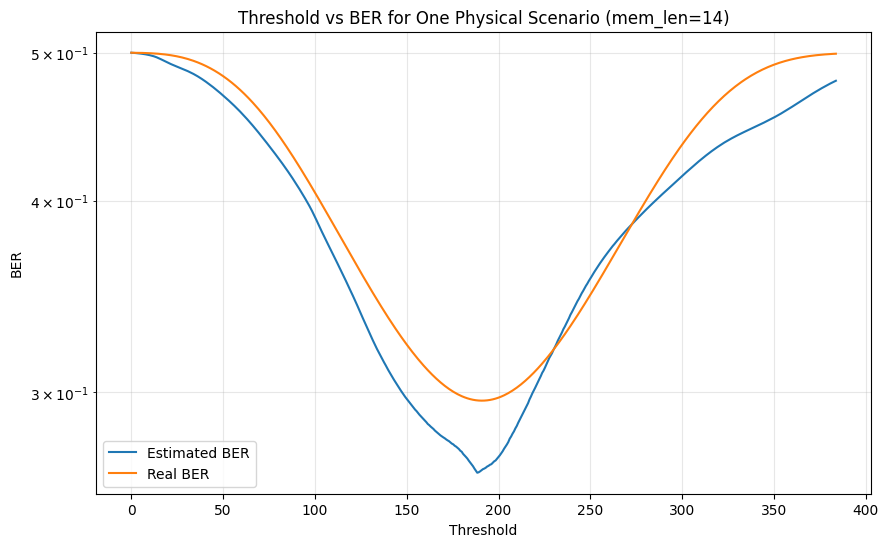

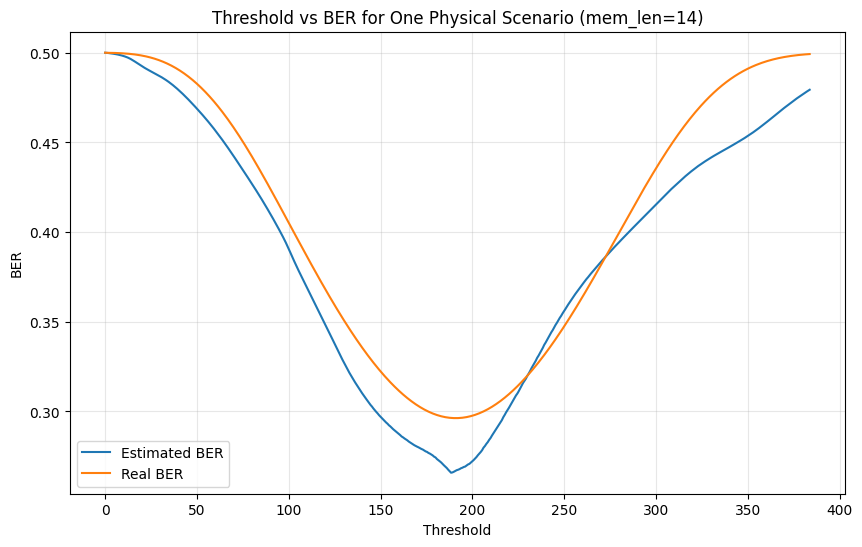

In [76]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> min_side_z
      3 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    # Updated to include all 4 global features
    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, min_side_z_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]

# Updated global_dim fallback to 4 based on training script
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 4), 
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [23]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Constants
# =========================
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Model Architecture Classes
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=4,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) 
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] 

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Team Alpacas: BER Inference Pipeline
# =========================

def predict_ber(df: pd.DataFrame, model_path: str, scaler_path: str, device: torch.device = None) -> np.ndarray:
    """
    Generates BER predictions for molecular communication decoding data.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    print(f"Loading scalers from: {scaler_path}")
    scalers = joblib.load(scaler_path)
    
    # Initialize the model using dimensions saved in the scalers
    seq_len = scalers["seq_len"]
    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=scalers["global_dim"],
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.0, # Dropout disabled for inference
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=scalers["pos_emb_dim"],
        use_self_attention=scalers["uses_self_attention"]
    ).to(device)
    
    print(f"Loading model weights from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Data Extraction
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]
    
    df_clean = df.copy()
    df_clean[tap_cols] = df_clean[tap_cols].fillna(0.0)
    df_clean[var_cols] = df_clean[var_cols].fillna(0.0)
    
    X_taps_raw = df_clean[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df_clean[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df_clean["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df_clean["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    # Feature Engineering
    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    # Global decision features
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw).astype(np.float32)

    # Apply Scalers
    t_taps = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    t_vars = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    t_abs = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    t_snr = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    t_z0 = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    t_z1 = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    t_msz = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)
    t_hmg = scalers["harmonic_minus_gap_scaler"].transform(harmonic_minus_gap_raw).astype(np.float32)
    t_thr = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    # Build Sequences
    n_samples = t_taps.shape[0]
    pos = np.linspace(0.0, 1.0, seq_len, dtype=np.float32)
    pos_ch = np.tile(pos, (n_samples, 1)).astype(np.float32)
    
    first_flag = np.zeros((n_samples, seq_len), dtype=np.float32)
    first_flag[:, 0] = 1.0
    
    seq_features = np.stack([
        t_taps, t_vars, pos_ch, t_abs, t_snr, first_flag
    ], axis=1).astype(np.float32)

    global_features = np.concatenate([
        t_z0, t_z1, t_msz, t_hmg
    ], axis=1).astype(np.float32)

    # Tensor Conversion & Model Execution
    b_seq = torch.from_numpy(seq_features).to(device)
    b_global = torch.from_numpy(global_features).to(device)
    b_thr = torch.from_numpy(t_thr).to(device)

    with torch.no_grad():
        pred_raw_unconstrained = model(b_seq, b_global, b_thr)
        pred_ber = model.raw_to_ber(pred_raw_unconstrained)

    return pred_ber.cpu().numpy()

# =========================
# Example Usage
# =========================
# =========================
# Example Usage (Real Dataset)
# =========================
# =========================
# Example Usage (Real Dataset)
# =========================
if __name__ == "__main__":
    # Define paths based on your configuration block
    DATA_PATH = "./data_physics_with_variances_total.csv"
    MODEL_PATH = "./ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M.pth"
    SCALER_PATH = "./ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"

    if not (os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH)):
        print("Critical Error: Model or scalers not found.")
        print("Run the training script first to generate the necessary artifacts.")
        exit()

    if not os.path.exists(DATA_PATH):
        print(f"Critical Error: Data file not found at {DATA_PATH}")
        exit()

    print(f"Extracting unseen holdout data from {DATA_PATH}...")
    
    # 1. Read the header to maintain column names
    header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
    
    # 2. Skip the 5,000,000 rows used in training (plus 1 for the header)
    try:
        test_df = pd.read_csv(
            DATA_PATH, 
            skiprows=5000001, 
            nrows=100000, 
            names=header
        )
    except pd.errors.EmptyDataError:
        print("Dataset does not contain more than 5,000,000 rows. Please provide a larger dataset.")
        exit()

    # 3. Apply the same base cleaning filters as the training data
    if "mem_len" in test_df.columns:
        test_df = test_df[test_df["mem_len"] != 1].copy()
    
    test_df = test_df[(test_df["threshold"] > 0) & (test_df["BER"] > 0) & (test_df["N"] > 0)].copy()
    
    # Apply the 10^-12 clamp to the ground truth targets (Matching Training Code)
    EPS = 1e-12
    test_df["BER"] = test_df["BER"].clip(lower=EPS, upper=0.5)
    
    if test_df.empty:
        print("No valid rows remaining after applying data cleaning filters.")
        exit()

    print(f"Successfully loaded {len(test_df)} unseen test samples.")

    # 4. Run Inference (Model output is automatically clamped to [EPS, 0.5])
    predictions = predict_ber(test_df, MODEL_PATH, SCALER_PATH)
    test_df["Predicted_BER"] = predictions.flatten()
    
    # 5. Calculate Metrics exactly like the Training evaluation
    preds_log = np.log10(test_df["Predicted_BER"].to_numpy())
    targets_log = np.log10(test_df["BER"].to_numpy())
    preds_raw = test_df["Predicted_BER"].to_numpy()
    targets_raw = test_df["BER"].to_numpy()

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    print("\n--- Holdout Performance Summary ---")
    print(
        f"Test RMSE(log10): {rmse_log:.4f} | "
        f"Test MAE(log10): {mae_log:.4f} | "
        f"Typical multiplicative error: ~{factor_error:.2f}x\n"
        f"Test RMSE(raw): {rmse_raw:.6f} | "
        f"Test MAE(raw): {mae_raw:.6f}"
    )

    # 6. Evaluate by target range (Matching Training Code Diagnostics)
    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    print("\nPer-range test diagnostics:")
    for name, mask in ranges.items():
        if np.any(mask):
            r_rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            r_mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            r_factor_error = float(10 ** r_rmse_log)
            r_rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            r_mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            
            print(
                f"{name} | count={int(mask.sum())} | "
                f"RMSE(log10)={r_rmse_log:.4f} | "
                f"MAE(log10)={r_mae_log:.4f} | "
                f"factor~{r_factor_error:.2f}x | "
                f"RMSE(raw)={r_rmse_raw:.6f} | "
                f"MAE(raw)={r_mae_raw:.6f}"
            )
        else:
            print(f"{name}: no samples")

    print("\n--- Sample Predictions ---")
    columns_to_display = ["N", "threshold", "BER", "Predicted_BER"]
    display_cols = [c for c in columns_to_display if c in test_df.columns]
    print(test_df[display_cols].head(15))

Extracting unseen holdout data from ./data_physics_with_variances_total.csv...
Successfully loaded 64205 unseen test samples.
Loading scalers from: ./ber_boundedloghalf_globalboth_scalers_v2_5M.pkl
Loading model weights from: ./ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M.pth

--- Holdout Performance Summary ---
Test RMSE(log10): 0.1293 | Test MAE(log10): 0.0669 | Typical multiplicative error: ~1.35x
Test RMSE(raw): 0.007562 | Test MAE(raw): 0.004691

Per-range test diagnostics:
low_BER(y<1e-6) | count=12860 | RMSE(log10)=0.2839 | MAE(log10)=0.2708 | factor~1.92x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=2123 | RMSE(log10)=0.0949 | MAE(log10)=0.0840 | factor~1.24x | RMSE(raw)=0.000054 | MAE(raw)=0.000030
high_BER(1e-3<=y<0.10) | count=8141 | RMSE(log10)=0.0355 | MAE(log10)=0.0244 | factor~1.09x | RMSE(raw)=0.001820 | MAE(raw)=0.001420
extreme_BER(y>=0.10) | count=41081 | RMSE(log10)=0.0138 | MAE(log10)=0.0106 | factor~1.03x | RMSE(raw)=0.00941

In [25]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Constants
# =========================
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Model Architecture Classes
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout)
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype))
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] 

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        return self.head(fused)

# =========================
# Team Alpacas: BER Inference Pipeline (v3)
# =========================

def predict_ber(df: pd.DataFrame, model_path: str, scaler_path: str, device: torch.device = None) -> np.ndarray:
    """
    Generates BER predictions for molecular communication decoding data (Global Dim 3).
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    print(f"Loading scalers from: {scaler_path}")
    scalers = joblib.load(scaler_path)
    
    # Initialize the model using dimensions saved in the scalers (global_dim=3)
    seq_len = scalers["seq_len"]
    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=scalers["global_dim"],
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.0, # Dropout disabled for inference
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=scalers["pos_emb_dim"],
        use_self_attention=scalers["uses_self_attention"]
    ).to(device)
    
    print(f"Loading model weights from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Data Extraction
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]
    
    df_clean = df.copy()
    df_clean[tap_cols] = df_clean[tap_cols].fillna(0.0)
    df_clean[var_cols] = df_clean[var_cols].fillna(0.0)
    
    X_taps_raw = df_clean[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df_clean[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df_clean["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df_clean["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    # Feature Engineering
    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    # Global decision features (Updated for v3 - min_side_z removed)
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw).astype(np.float32)

    # Apply Scalers
    t_taps = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    t_vars = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    t_abs = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    t_snr = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    t_z0 = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    t_z1 = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    t_hmg = scalers["harmonic_minus_gap_scaler"].transform(harmonic_minus_gap_raw).astype(np.float32)
    t_thr = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    # Build Sequences
    n_samples = t_taps.shape[0]
    pos = np.linspace(0.0, 1.0, seq_len, dtype=np.float32)
    pos_ch = np.tile(pos, (n_samples, 1)).astype(np.float32)
    
    first_flag = np.zeros((n_samples, seq_len), dtype=np.float32)
    first_flag[:, 0] = 1.0
    
    seq_features = np.stack([
        t_taps, t_vars, pos_ch, t_abs, t_snr, first_flag
    ], axis=1).astype(np.float32)

    # Global array updated to exactly match the 3 dimensions
    global_features = np.concatenate([
        t_z0, t_z1, t_hmg
    ], axis=1).astype(np.float32)

    # Tensor Conversion & Model Execution
    b_seq = torch.from_numpy(seq_features).to(device)
    b_global = torch.from_numpy(global_features).to(device)
    b_thr = torch.from_numpy(t_thr).to(device)

    with torch.no_grad():
        pred_raw_unconstrained = model(b_seq, b_global, b_thr)
        pred_ber = model.raw_to_ber(pred_raw_unconstrained)

    return pred_ber.cpu().numpy()

# =========================
# Example Usage (Real Dataset)
# =========================
if __name__ == "__main__":
    # Define paths based on your configuration block (v3 files)
    DATA_PATH = "./data_physics_with_variances_total.csv"
    MODEL_PATH = "./ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth"
    SCALER_PATH = "./ber_boundedloghalf_globalhmg_scalers_5M.pkl"

    if not (os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH)):
        print("Critical Error: Model or scalers not found.")
        print(f"Looking for: \n- {MODEL_PATH}\n- {SCALER_PATH}")
        print("Run the training script first to generate the necessary artifacts.")
        exit()

    if not os.path.exists(DATA_PATH):
        print(f"Critical Error: Data file not found at {DATA_PATH}")
        exit()

    print(f"Extracting unseen holdout data from {DATA_PATH}...")
    
    # 1. Read the header to maintain column names
    header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
    
    # 2. Skip the 5,000,000 rows used in training (plus 1 for the header)
    try:
        test_df = pd.read_csv(
            DATA_PATH, 
            skiprows=5000001, 
            nrows=100000, 
            names=header
        )
    except pd.errors.EmptyDataError:
        print("Dataset does not contain more than 5,000,000 rows. Please provide a larger dataset.")
        exit()

    # 3. Apply the same base cleaning filters as the training data
    if "mem_len" in test_df.columns:
        test_df = test_df[test_df["mem_len"] != 1].copy()
    
    test_df = test_df[(test_df["threshold"] > 0) & (test_df["BER"] > 0) & (test_df["N"] > 0)].copy()
    
    # Apply the 10^-12 clamp to the ground truth targets
    test_df["BER"] = test_df["BER"].clip(lower=EPS, upper=0.5)
    
    if test_df.empty:
        print("No valid rows remaining after applying data cleaning filters.")
        exit()

    print(f"Successfully loaded {len(test_df)} unseen test samples.")

    # 4. Run Inference
    predictions = predict_ber(test_df, MODEL_PATH, SCALER_PATH)
    test_df["Predicted_BER"] = predictions.flatten()
    
    # 5. Calculate Metrics
    preds_log = np.log10(test_df["Predicted_BER"].to_numpy())
    targets_log = np.log10(test_df["BER"].to_numpy())
    preds_raw = test_df["Predicted_BER"].to_numpy()
    targets_raw = test_df["BER"].to_numpy()

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    print("\n--- Holdout Performance Summary ---")
    print(
        f"Test RMSE(log10): {rmse_log:.4f} | "
        f"Test MAE(log10): {mae_log:.4f} | "
        f"Typical multiplicative error: ~{factor_error:.2f}x\n"
        f"Test RMSE(raw): {rmse_raw:.6f} | "
        f"Test MAE(raw): {mae_raw:.6f}"
    )

    # 6. Evaluate by target range
    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    print("\nPer-range test diagnostics:")
    for name, mask in ranges.items():
        if np.any(mask):
            r_rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            r_mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            r_factor_error = float(10 ** r_rmse_log)
            r_rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            r_mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            
            print(
                f"{name} | count={int(mask.sum())} | "
                f"RMSE(log10)={r_rmse_log:.4f} | "
                f"MAE(log10)={r_mae_log:.4f} | "
                f"factor~{r_factor_error:.2f}x | "
                f"RMSE(raw)={r_rmse_raw:.6f} | "
                f"MAE(raw)={r_mae_raw:.6f}"
            )
        else:
            print(f"{name}: no samples")

    print("\n--- Sample Predictions ---")
    columns_to_display = ["N", "threshold", "BER", "Predicted_BER"]
    display_cols = [c for c in columns_to_display if c in test_df.columns]
    print(test_df[display_cols].head(15))

Extracting unseen holdout data from ./data_physics_with_variances_total.csv...
Successfully loaded 64205 unseen test samples.
Loading scalers from: ./ber_boundedloghalf_globalhmg_scalers_5M.pkl
Loading model weights from: ./ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth

--- Holdout Performance Summary ---
Test RMSE(log10): 0.1294 | Test MAE(log10): 0.0630 | Typical multiplicative error: ~1.35x
Test RMSE(raw): 0.007596 | Test MAE(raw): 0.003699

Per-range test diagnostics:
low_BER(y<1e-6) | count=12860 | RMSE(log10)=0.2865 | MAE(log10)=0.2714 | factor~1.93x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=2123 | RMSE(log10)=0.0615 | MAE(log10)=0.0516 | factor~1.15x | RMSE(raw)=0.000035 | MAE(raw)=0.000018
high_BER(1e-3<=y<0.10) | count=8141 | RMSE(log10)=0.0281 | MAE(log10)=0.0180 | factor~1.07x | RMSE(raw)=0.001548 | MAE(raw)=0.001014
extreme_BER(y>=0.10) | count=41081 | RMSE(log10)=0.0108 | MAE(log10)=0.0072 | factor~1.03x | RMSE(raw)=0.009472 | MAE(raw)=

In [ ]:
Extracting unseen holdout data from ./data_physics_with_variances_total.csv...
Successfully loaded 64205 unseen test samples.
Loading scalers from: ./ber_boundedloghalf_globalboth_scalers_v2_5M.pkl
Loading model weights from: ./ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M.pth

--- Holdout Performance Summary ---
Test RMSE(log10): 0.1293 | Test MAE(log10): 0.0669 | Typical multiplicative error: ~1.35x
Test RMSE(raw): 0.007562 | Test MAE(raw): 0.004691

Per-range test diagnostics:
low_BER(y<1e-6) | count=12860 | RMSE(log10)=0.2839 | MAE(log10)=0.2708 | factor~1.92x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=2123 | RMSE(log10)=0.0949 | MAE(log10)=0.0840 | factor~1.24x | RMSE(raw)=0.000054 | MAE(raw)=0.000030
high_BER(1e-3<=y<0.10) | count=8141 | RMSE(log10)=0.0355 | MAE(log10)=0.0244 | factor~1.09x | RMSE(raw)=0.001820 | MAE(raw)=0.001420
extreme_BER(y>=0.10) | count=41081 | RMSE(log10)=0.0138 | MAE(log10)=0.0106 | factor~1.03x | RMSE(raw)=0.009419 | MAE(raw)=0.007048

--- Sample Predictions ---
         N     threshold           BER  Predicted_BER
1    88000  14392.215477  3.749858e-01   3.656707e-01
3    78463  27892.589986  5.000000e-01   5.000000e-01
6    60641   3611.784325  3.824702e-01   3.680850e-01
8     2165    401.228823  1.083377e-01   1.062504e-01
9    54591   8236.623662  1.016811e-09   8.352488e-10
10   25096   3991.941495  1.371147e-01   1.365268e-01
11   30497   4485.987040  1.000000e-12   2.009602e-12
12    7874   2268.550402  5.000000e-01   5.000000e-01
15  380893  18316.976759  1.839313e-01   1.785447e-01
16   74073    440.333323  4.687500e-01   4.510752e-01
17   47831   3796.014538  5.481255e-02   5.670196e-02
18    9646   2572.355166  6.349161e-02   6.564089e-02
19    5737    231.573273  2.221247e-01   2.109607e-01
20    4205    166.136958  3.351062e-01   3.196133e-01
21   40063   3525.625118  5.365140e-02   5.542044e-02

# ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M plot weird

Using device: cuda

--- Running Scenarios for Seed 42 ---


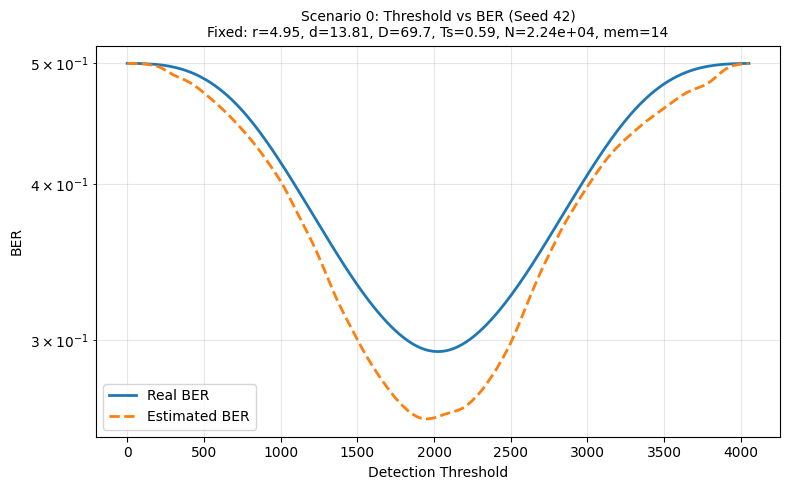

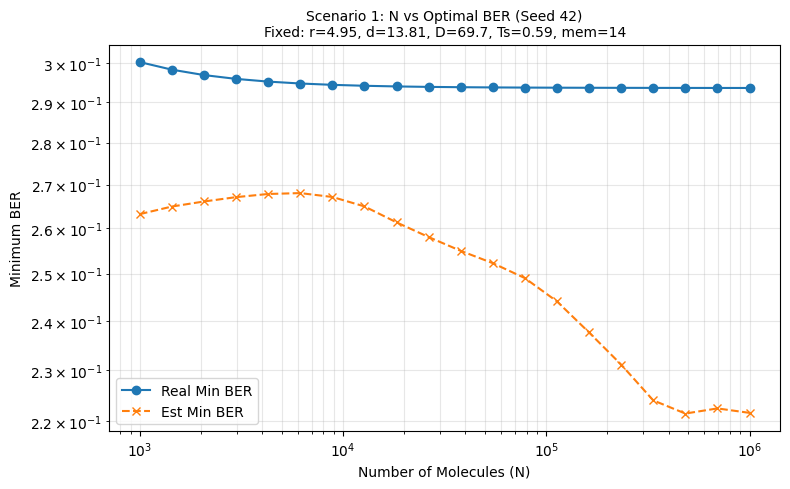

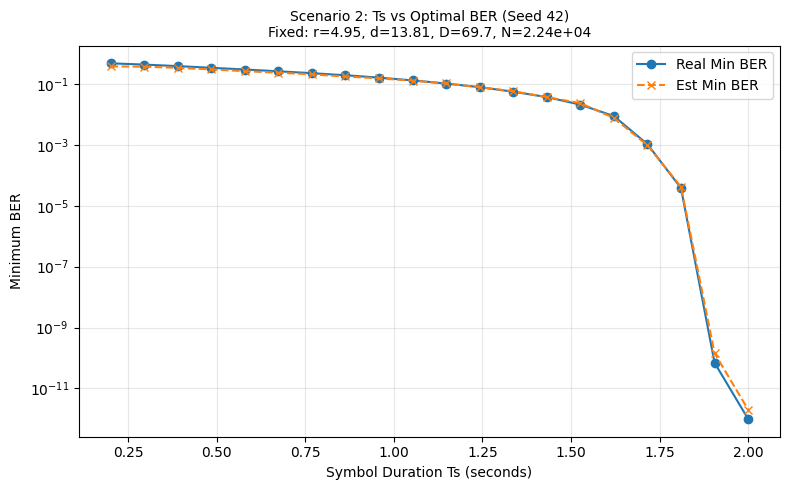

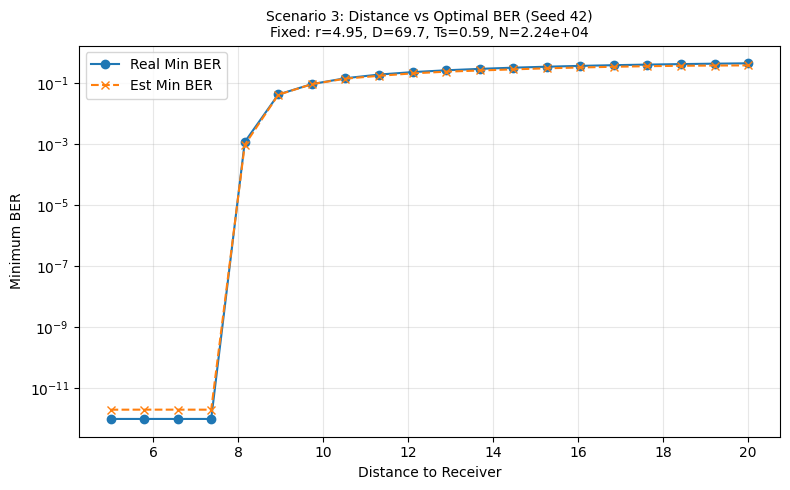


--- Running Scenarios for Seed 100 ---


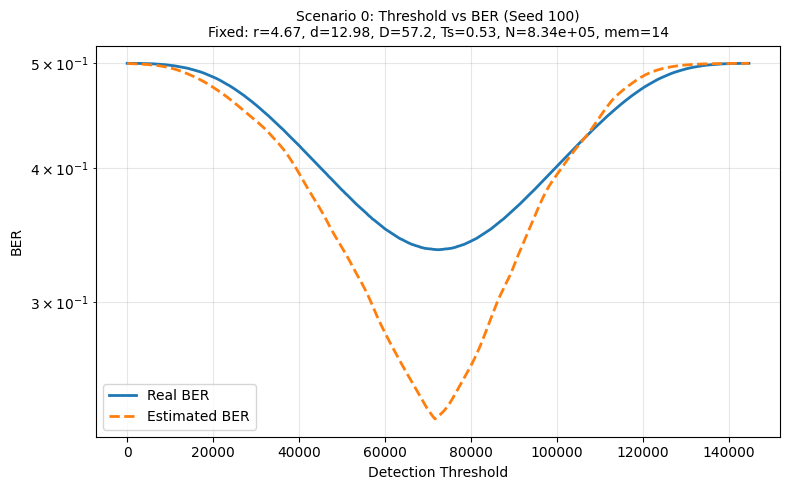

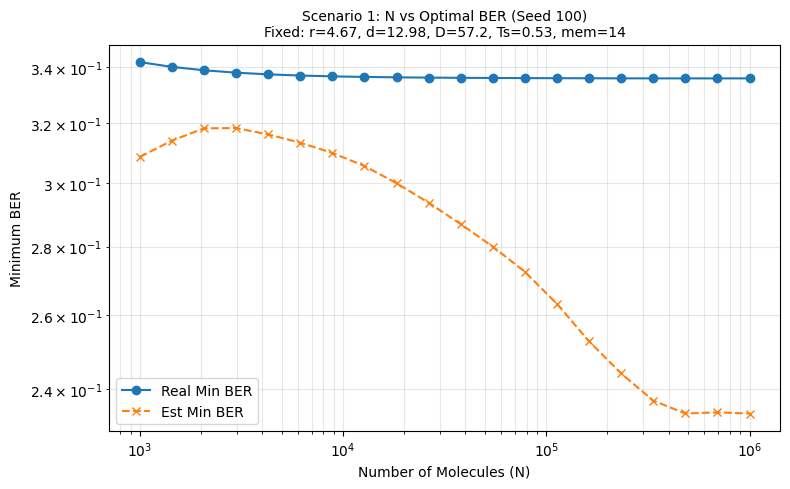

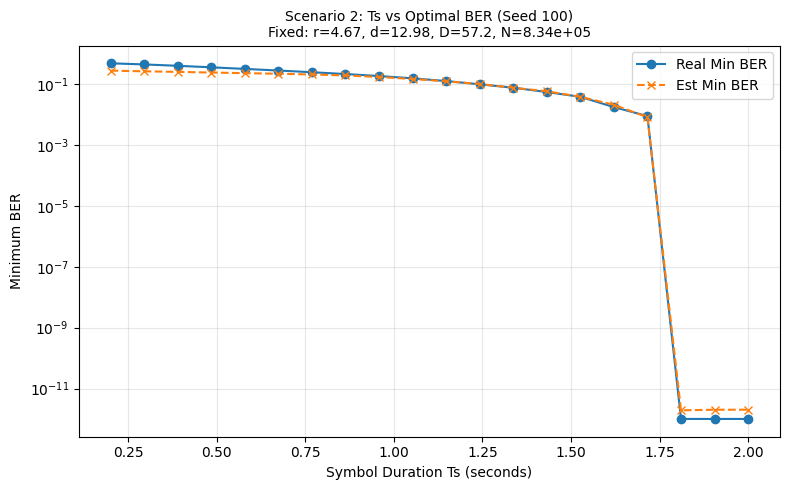

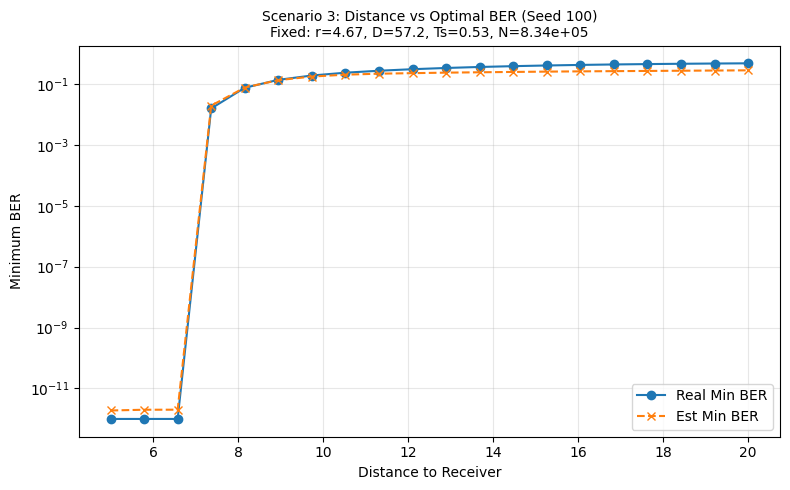

In [1]:
import os

import joblib

import numpy as np

import pandas as pd

import torch

import torch.nn as nn

import torch.nn.functional as F

import matplotlib.pyplot as plt

from scipy.special import erfc

from itertools import product as iproduct



EPS = 1e-12



# =========================Test Loss: 0.0005 | Test RMSE(log10): 0.0319 | Test MAE(log10): 0.0163 | Typical multiplicative error: ~1.08x | Test RMSE(raw): 0.007610 | Test MAE(raw): 0.004725

Per-range test diagnostics:
low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0475 | MAE(log10)=0.0185 | factor~1.12x | RMSE(raw)=0.000000 | MAE(raw)=0.000000
mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.0931 | MAE(log10)=0.0826 | factor~1.24x | RMSE(raw)=0.000054 | MAE(raw)=0.000030
high_BER(1e-3<=y<0.10) | count=60956 | RMSE(log10)=0.0361 | MAE(log10)=0.0248 | factor~1.09x | RMSE(raw)=0.001810 | MAE(raw)=0.001425
extreme_BER(y>=0.10) | count=311183 | RMSE(log10)=0.0138 | MAE(log10)=0.0106 | factor~1.03x | RMSE(raw)=0.009458 | MAE(raw)=0.007071
Scalers saved to: ./ber_boundedloghalf_globalboth_scalers_v2_5M.pkl

# Paths

# =========================

MODEL_PATH = "ber_boundedloghalf_globalboth_finetuned_v2plusplus_best_5M.pth"

SCALER_PATH = "ber_boundedloghalf_globalboth_scalers_v2_5M.pkl"



# =========================

# Config

# =========================

PHYSICS_MAX_MEM_LEN = 14

PHYSICS_MIN_MEM_LEN = 14

ARRIVAL_COVERAGE = 0.70

N_THRESHOLDS = 500

RANDOM_SEED = 60



# =========================

# Physics helpers

# =========================

def Fhit_function(radius, distance, diffusionCoef, t):

    if t <= 0:

        return 0.0

    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))



def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):

    P = np.zeros(mem_len)

    for i in range(mem_len):

        t_end = (i + 1) * Ts

        t_start = i * Ts

        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(

            radius, distance, diffusionCoef, t_start

        )

    return P



def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):

    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]

    vars_arr = np.asarray(variances, dtype=float)[:mem_len]



    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]

    c_bit = seqs[:, 0]



    mu = (seqs * P_arr).sum(axis=1)

    var_total = (seqs * vars_arr).sum(axis=1)

    std = np.sqrt(np.maximum(var_total, 0.0))



    pe = np.empty_like(mu)



    zero_std = (std == 0)

    if np.any(zero_std):

        pe[zero_std & (c_bit == 1)] = np.where(

            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0

        )

        pe[zero_std & (c_bit == 0)] = np.where(

            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0

        )



    nz = ~zero_std

    if np.any(nz):

        pe[nz & (c_bit == 1)] = 0.5 * erfc(

            (mu[nz & (c_bit == 1)] - threshold) /

            (std[nz & (c_bit == 1)] * np.sqrt(2))

        )

        pe[nz & (c_bit == 0)] = 0.5 * erfc(

            (threshold - mu[nz & (c_bit == 0)]) /

            (std[nz & (c_bit == 0)] * np.sqrt(2))

        )



    return float(np.mean(pe))



def add_fixed_width_columns(row, values, max_len, prefix):

    for i in range(max_len):

        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan

    return row



# =========================

# Case Generators

# =========================

def generate_physical_case(rng, min_mem_len=10, max_mem_len=14, arrival_coverage=0.70, max_tries=5000):

    for _ in range(max_tries):

        radius = rng.uniform(3.0, 5.0)

        distance = rng.uniform(10.0, 15.0)

        diff = rng.uniform(50.0, 75.0)

        Ts = rng.uniform(0.5, 1.2)

        N = int(10 ** rng.uniform(3.0, 6.0))



        f_inf = radius / (radius + distance)

        target = arrival_coverage * f_inf



        cumsum, k = 0.0, 0

        while k < max_mem_len:

            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(

                radius, distance, diff, k * Ts

            )

            cumsum += pk

            k += 1

            if cumsum >= target:

                break



        if k < min_mem_len:

            continue



        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)

        P_main = P_ext[:k]

        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0



        P_scaled = P_main * N

        variances = N * P_main * (1.0 - P_main)



        return {

            "radius": radius,

            "distance": distance,

            "diffusion": diff,

            "Ts": Ts,

            "N": N,

            "mem_len": k,

            "P": P_main,

            "P_scaled": P_scaled,

            "variances": variances,

            "P_mem_len_extra": P_extra,

            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),

        }



    raise RuntimeError(f"Could not generate a physical case with mem_len >= {min_mem_len} after {max_tries} tries.")



def compute_case_from_params(radius, distance, diff, Ts, N, max_mem_len=14, arrival_coverage=0.70):

    f_inf = radius / (radius + distance)

    target = arrival_coverage * f_inf



    cumsum, k = 0.0, 0

    while k < max_mem_len:

        pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(

            radius, distance, diff, k * Ts

        )

        cumsum += pk

        k += 1

        if cumsum >= target:

            break



    P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)

    P_main = P_ext[:k]

    P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0



    P_scaled = P_main * N

    variances = N * P_main * (1.0 - P_main)



    return {

        "radius": radius,

        "distance": distance,

        "diffusion": diff,

        "Ts": Ts,

        "N": N,

        "mem_len": k,

        "P": P_main,

        "P_scaled": P_scaled,

        "variances": variances,

        "P_mem_len_extra": P_extra,

        "P_mem_len_extra_var": P_extra * (1.0 - P_extra),

    }



# =========================

# Model blocks

# =========================

class SqueezeExcite1D(nn.Module):

    def __init__(self, channels, reduction=8):

        super().__init__()

        hidden = max(channels // reduction, 8)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(

            nn.Conv1d(channels, hidden, kernel_size=1), nn.GELU(),

            nn.Conv1d(hidden, channels, kernel_size=1), nn.Sigmoid()

        )



    def forward(self, x):

        scale = self.pool(x)

        scale = self.fc(scale)

        return x * scale



class ConvBNAct(nn.Module):

    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):

        super().__init__()

        padding = ((kernel_size - 1) // 2) * dilation

        self.block = nn.Sequential(

            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, stride=stride,

                      padding=padding, dilation=dilation, groups=groups, bias=False),

            nn.BatchNorm1d(out_ch), nn.GELU()

        )



    def forward(self, x):

        return self.block(x)



class MultiScaleResidualBlock(nn.Module):

    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):

        super().__init__()

        b1, b2 = out_ch // 3, out_ch // 3

        b3 = out_ch - b1 - b2



        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)

        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)

        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)



        self.mix = nn.Sequential(

            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),

            nn.BatchNorm1d(out_ch), nn.GELU(), nn.Dropout(dropout)

        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (

            nn.Sequential(nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False), nn.BatchNorm1d(out_ch))

            if in_ch != out_ch else nn.Identity()

        )

        self.out_act = nn.GELU()



    def forward(self, x):

        residual = self.skip(x)

        out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)

        out = self.mix(out)

        out = self.se(out)

        out = out + residual

        out = self.out_act(out)

        return out



class DownsampleResidualBlock(nn.Module):

    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):

        super().__init__()

        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)

        self.down = nn.Sequential(

            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),

            nn.BatchNorm1d(out_ch), nn.GELU()

        )



    def forward(self, x):

        x = self.pre(x)

        x = self.down(x)

        return x



class ThresholdFiLM(nn.Module):

    def __init__(self, condition_dim, feature_dim, hidden_dim=64):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(condition_dim, hidden_dim), nn.GELU(),

            nn.Linear(hidden_dim, feature_dim * 2)

        )

        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))



    def forward(self, x, cond):

        gamma_beta = self.net(cond)

        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)

        gamma = gamma.unsqueeze(-1)

        beta = beta.unsqueeze(-1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta



class SequenceStem(nn.Module):

    def __init__(self, in_ch, stem_ch=32):

        super().__init__()

        self.net = nn.Sequential(

            ConvBNAct(in_ch, stem_ch, kernel_size=5),

            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)

        )



    def forward(self, x):

        return self.net(x)



class LightSelfAttention1D(nn.Module):

    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):

        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True)

        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)

        self.mlp = nn.Sequential(

            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),

            nn.Linear(hidden, dim), nn.Dropout(dropout)

        )



    def forward(self, x):

        x_seq = x.transpose(1, 2)

        y = self.norm1(x_seq)

        attn_out, _ = self.attn(y, y, y, need_weights=False)

        x_seq = x_seq + attn_out

        x_seq = x_seq + self.mlp(self.norm2(x_seq))

        return x_seq.transpose(1, 2)



class MultiHeadAttentionPooling(nn.Module):

    def __init__(self, input_dim, attn_dim=128, num_heads=4):

        super().__init__()

        self.score = nn.Sequential(

            nn.Conv1d(input_dim, attn_dim, kernel_size=1), nn.GELU(),

            nn.Conv1d(attn_dim, num_heads, kernel_size=1)

        )

        self.num_heads = num_heads

        self.input_dim = input_dim



    def forward(self, x):

        logits = self.score(x)

        weights = torch.softmax(logits, dim=-1)

        pooled = torch.einsum("bhl,bcl->bhc", weights, x)

        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)

        return pooled



class StagePooling(nn.Module):

    def __init__(self, channels, num_attn_heads=2, attn_dim=64):

        super().__init__()

        self.attn_pool = MultiHeadAttentionPooling(input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads)

        self.out_dim = num_attn_heads * channels + 3 * channels



    def forward(self, x):

        attn = self.attn_pool(x)

        mean = x.mean(dim=-1)

        std = x.std(dim=-1, unbiased=False)

        maxv = x.amax(dim=-1)

        return torch.cat([attn, mean, std, maxv], dim=1)



class BERMultiScaleResCNNBoundedLogHalf(nn.Module):

    def __init__(self, seq_len, threshold_dim=1, global_dim=4, stem_ch=32, channels=(64, 96, 128),

                 dropout=0.10, stage_pool_heads=(2, 2, 2, 4), attn_heads=4, pos_emb_dim=8, use_self_attention=True):

        super().__init__()

        self.seq_len = seq_len

        self.pos_emb_dim = pos_emb_dim

        self.use_self_attention = use_self_attention



        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)



        self.extra_proj = nn.Sequential(

            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),

            nn.BatchNorm1d(stem_ch), nn.GELU()

        )



        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)

        self.pos_emb_proj = nn.Sequential(

            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),

            nn.BatchNorm1d(stem_ch), nn.GELU()

        )



        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(nn.Linear(threshold_dim, 32), nn.GELU(), nn.Linear(32, 32), nn.GELU())

        self.global_embed = nn.Sequential(nn.Linear(global_dim, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU())



        cond_dim = 32 + 64



        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)

        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)



        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)

        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)



        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)

        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)



        self.self_attn = LightSelfAttention1D(dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout) if use_self_attention else nn.Identity()



        self.bottleneck = nn.Sequential(

            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),

            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),

        )



        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)

        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)

        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)

        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)



        head_in = self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim



        self.head = nn.Sequential(

            nn.Linear(head_in, 512), nn.GELU(), nn.Dropout(0.20),

            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.15),

            nn.Linear(256, 128), nn.GELU(), nn.Linear(128, 1)

        )



    @staticmethod

    def raw_to_log10ber(pred_raw_unconstrained):

        log10_half = torch.log10(torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype))

        return log10_half - F.softplus(pred_raw_unconstrained)



    @staticmethod

    def raw_to_ber(pred_raw_unconstrained):

        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)

        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)



    def forward(self, seq, global_feats, threshold):

        mean_x = seq[:, 0:1, :]

        var_x = seq[:, 1:2, :]

        extra_x = seq[:, 2:6, :]



        mean_f = self.mean_stem(mean_x)

        var_f = self.var_stem(var_x)

        extra_f = self.extra_proj(extra_x)



        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)

        pos_f = self.pos_emb_proj(pos_emb)



        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)



        thr = self.thr_embed(threshold)

        g = self.global_embed(global_feats)

        cond = torch.cat([thr, g], dim=1)



        x1 = self.stage1(x)

        x1 = self.film1(x1, cond)



        x2 = self.stage2(x1)

        x2 = self.film2(x2, cond)



        x3 = self.stage3(x2)

        x3 = self.film3(x3, cond)



        x3 = self.self_attn(x3)

        xb = self.bottleneck(x3)



        p1 = self.pool1(x1)

        p2 = self.pool2(x2)

        p3 = self.pool3(x3)

        pb = self.poolb(xb)



        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)

        pred_raw_unconstrained = self.head(fused)

        return pred_raw_unconstrained



# =========================

# Build model inputs

# =========================

def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):

    tap_cols = scaler_meta["tap_cols"]

    max_len = len(tap_cols)



    rows = []

    for thr in thresholds:

        row = {

            "mem_len": case["mem_len"],

            "threshold": float(thr),

            "BER": np.nan,

            "radius": case["radius"],

            "distance": case["distance"],

            "diffusion": case["diffusion"],

            "Ts": case["Ts"],

            "N": case["N"],

            "P_mem_len_extra": case["P_mem_len_extra"],

            "P_mem_len_extra_var": case["P_mem_len_extra_var"],

        }

        row = add_fixed_width_columns(row, case["P"], max_len, "tap")

        row = add_fixed_width_columns(row, case["variances"], max_len, "var")

        rows.append(row)

    return pd.DataFrame(rows)



def prepare_inference_features(df, scalers):

    tap_cols = scalers["tap_cols"]

    var_cols = scalers["var_cols"]



    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)

    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)



    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)



    if np.any(X_vars_raw < 0):

        raise ValueError("Variance columns contain negative values.")



    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)

    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)



    first_mean = X_taps_feat[:, 0:1]

    past_means = X_taps_feat[:, 1:]

    first_var = X_vars_feat[:, 0:1]

    past_vars = X_vars_feat[:, 1:]



    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)

    mu1_raw = (first_mean + mu0_raw).astype(np.float32)



    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)

    var1_raw = (first_var + var0_raw).astype(np.float32)



    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)

    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)



    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)

    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)



    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)

    harmonic_side_z_raw = (2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw).astype(np.float32)



    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)

    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)

    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)

    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)



    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)

    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)

    min_side_z_scaled = scalers["min_side_z_scaler"].transform(min_side_z_raw).astype(np.float32)

    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(harmonic_minus_gap_raw).astype(np.float32)

    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)



    L = taps_scaled.shape[1]

    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)



    first_flag = np.zeros((len(df), L), dtype=np.float32)

    first_flag[:, 0] = 1.0



    seq = np.stack([taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag], axis=1).astype(np.float32)

    

    # 4 Global Features integrated here

    global_feats = np.concatenate([z0_scaled, z1_scaled, min_side_z_scaled, harmonic_minus_gap_scaled], axis=1).astype(np.float32)



    return seq, global_feats, thr_scaled



# =========================

# Scenario Plotting Functions

# =========================

def get_minimum_ber_for_case(case, model, scalers, device, n_thresholds=200):

    """Sweeps thresholds for a single case and returns the lowest Real and Predicted BER."""

    thr_max = float(np.sum(case["P_scaled"]))

    thresholds = np.linspace(0.0, thr_max, n_thresholds)

    

    real_bers = [

        calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"])

        for thr in thresholds

    ]

    real_bers = np.clip(real_bers, EPS, 0.5)

    

    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)

    seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

    

    seq_t = torch.from_numpy(seq).to(device)

    global_t = torch.from_numpy(global_feats).to(device)

    thr_t = torch.from_numpy(thr_scaled).to(device)

    

    with torch.no_grad():

        pred_raw_out = model(seq_t, global_t, thr_t)

        pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)

    

    pred_bers = np.clip(pred_bers, EPS, 0.5)

    

    return np.min(real_bers), np.min(pred_bers)



def plot_scenario_0_threshold(seed, model, scalers, device):

    """Scenario 0: Fix physics, sweep threshold."""

    rng = np.random.default_rng(seed)

    case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)

    

    thr_max = float(np.sum(case["P_scaled"]))

    thresholds = np.linspace(0.0, thr_max, 300)

    

    real_bers = [calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"]) for thr in thresholds]

    real_bers = np.clip(real_bers, EPS, 0.5)

    

    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)

    seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

    

    seq_t = torch.from_numpy(seq).to(device)

    global_t = torch.from_numpy(global_feats).to(device)

    thr_t = torch.from_numpy(thr_scaled).to(device)

    

    with torch.no_grad():

        pred_raw_out = model(seq_t, global_t, thr_t)

        pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)

    

    pred_bers = np.clip(pred_bers, EPS, 0.5)

    

    plt.figure(figsize=(8, 5))

    plt.plot(thresholds, real_bers, label="Real BER", linewidth=2)

    plt.plot(thresholds, pred_bers, label="Estimated BER", linestyle="--", linewidth=2)

    plt.yscale("log")

    plt.xlabel("Detection Threshold")

    plt.ylabel("BER")

    title = (f"Scenario 0: Threshold vs BER (Seed {seed})\n"

             f"Fixed: r={case['radius']:.2f}, d={case['distance']:.2f}, "

             f"D={case['diffusion']:.1f}, Ts={case['Ts']:.2f}, "

             f"N={case['N']:.2e}, mem={case['mem_len']}")

    plt.title(title, fontsize=10)

    plt.legend()

    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()

    plt.show()



def plot_scenario_1_N(seed, model, scalers, device):

    """Scenario 1: Fix physics, sweep Number of Molecules (Waterfall curve)."""

    rng = np.random.default_rng(seed)

    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)

    

    N_values = np.logspace(3, 6, 20) 

    real_mins, pred_mins = [], []

    

    for n in N_values:

        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], base_case["Ts"], n)

        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)

        real_mins.append(r_min)

        pred_mins.append(p_min)

        

    plt.figure(figsize=(8, 5))

    plt.plot(N_values, real_mins, label="Real Min BER", marker='o')

    plt.plot(N_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")

    plt.xscale("log")

    plt.yscale("log")

    plt.xlabel("Number of Molecules (N)")

    plt.ylabel("Minimum BER")

    title = (f"Scenario 1: N vs Optimal BER (Seed {seed})\n"

             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "

             f"D={base_case['diffusion']:.1f}, Ts={base_case['Ts']:.2f}, mem={base_case['mem_len']}")

    plt.title(title, fontsize=10)

    plt.legend()

    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()

    plt.show()



def plot_scenario_2_Ts(seed, model, scalers, device):

    """Scenario 2: Fix physics, sweep Symbol Duration (ISI Stress Test)."""

    rng = np.random.default_rng(seed)

    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)

    

    Ts_values = np.linspace(0.2, 2.0, 20) 

    real_mins, pred_mins = [], []

    

    for ts in Ts_values:

        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], ts, base_case["N"])

        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)

        real_mins.append(r_min)

        pred_mins.append(p_min)

        

    plt.figure(figsize=(8, 5))

    plt.plot(Ts_values, real_mins, label="Real Min BER", marker='o')

    plt.plot(Ts_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")

    plt.yscale("log")

    plt.xlabel("Symbol Duration Ts (seconds)")

    plt.ylabel("Minimum BER")

    title = (f"Scenario 2: Ts vs Optimal BER (Seed {seed})\n"

             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "

             f"D={base_case['diffusion']:.1f}, N={base_case['N']:.2e}")

    plt.title(title, fontsize=10)

    plt.legend()

    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()

    plt.show()



def plot_scenario_3_Distance(seed, model, scalers, device):

    """Scenario 3: Fix physics, sweep Distance (Signal Decay)."""

    rng = np.random.default_rng(seed)

    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)

    

    dist_values = np.linspace(5.0, 20.0, 20) 

    real_mins, pred_mins = [], []

    

    for d in dist_values:

        case = compute_case_from_params(base_case["radius"], d, base_case["diffusion"], base_case["Ts"], base_case["N"])

        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)

        real_mins.append(r_min)

        pred_mins.append(p_min)

        

    plt.figure(figsize=(8, 5))

    plt.plot(dist_values, real_mins, label="Real Min BER", marker='o')

    plt.plot(dist_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")

    plt.yscale("log")

    plt.xlabel("Distance to Receiver")

    plt.ylabel("Minimum BER")

    title = (f"Scenario 3: Distance vs Optimal BER (Seed {seed})\n"

             f"Fixed: r={base_case['radius']:.2f}, D={base_case['diffusion']:.1f}, "

             f"Ts={base_case['Ts']:.2f}, N={base_case['N']:.2e}")

    plt.title(title, fontsize=10)

    plt.legend()

    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()

    plt.show()



# =========================

# Main Execution

# =========================

if __name__ == "__main__":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"Using device: {device}")

    

    # Load scalers

    scalers = joblib.load(SCALER_PATH)

    

    # Initialize Model (v2plusplus has global_dim=4)

    model = BERMultiScaleResCNNBoundedLogHalf(

        seq_len=scalers["seq_len"],

        threshold_dim=1,

        global_dim=4, 

        stem_ch=32,

        channels=(64, 96, 128),

        dropout=0.10,

        stage_pool_heads=(2, 2, 2, 4),

        attn_heads=4,

        pos_emb_dim=scalers.get("pos_emb_dim", 8),

        use_self_attention=scalers.get("uses_self_attention", True),

    ).to(device)

    

    # Load Weights

    state = torch.load(MODEL_PATH, map_location=device)

    model.load_state_dict(state)

    model.eval()



    # Define random seeds to test

    test_seeds = [42, 100]

    

    for seed in test_seeds:

        print(f"\n--- Running Scenarios for Seed {seed} ---")

        plot_scenario_0_threshold(seed, model, scalers, device)

        plot_scenario_1_N(seed, model, scalers, device)

        plot_scenario_2_Ts(seed, model, scalers, device)

        plot_scenario_3_Distance(seed, model, scalers, device)